# Cross-Cohort Niche Label Transfer: H&E-Supervised Spatial Tissue Analysis

## Abstract

Spatial transcriptomics (e.g., Xenium) provides rich biological context but is cost-prohibitive at scale.
H&E staining is universally available. This notebook demonstrates a four-step pipeline that uses
Xenium data only during label construction, then trains a model that predicts biologically meaningful
niche types from H&E-derived cell-neighbor composition features alone.

The cohort consists of 4 biological samples (S1–S4), each sectioned at three tissue levels
(Top / Mid / Bot), yielding **12 tissue pieces** labeled P1–P12. Two independent groups are formed:

- **Group 1 (G1)**: P1–P6 (samples S1, S2)
- **Group 2 (G2)**: P7–P12 (samples S3, S4)

WSInsight niche discovery is run **independently** on each group, so niche IDs are not shared across groups.

## Core Scientific Contribution

1. **Independent niche discovery** per cohort group prevents label leakage between groups.
2. **Within-group label consistency** (G1A vs G1B): GOEA+LLM labeling is run independently on
   two halves of G1 that share the same niche ID space. Agreement in human-readable labels for the
   same niche ID confirms that cell-neighbor composition reliably encodes biological niche identity.
3. **Cross-group label transfer** (G1 → G2): A neural network trained on G1 H&E features predicts
   niche types on G2. G2's independently derived GOEA+LLM labels serve as held-out ground truth.

## Problem Statement

Let $\phi_i \in \mathbb{R}^{2d}$ be the neighbor-composition feature vector for niche group $i$
(mean and standard deviation of $d$ H&E-derived features over all member cells):
$$
\phi_i = [\mu_{i,1}, \dots, \mu_{i,d},\ \sigma_{i,1}, \dots, \sigma_{i,d}]
$$

Learn a function $f_\theta(\phi_i) \rightarrow y_i$ where $y_i$ is a human-readable niche type
(e.g., *tumor proliferative*, *immune interferon*, *TLS lymphoid*).

At inference time, Xenium is **not required**.

---

## Pipeline Overview

| Step | Input | Method | Output | Validation |
|------|-------|--------|--------|------------|
| 0 | P1–P12 H&E | WSInsight (2 independent runs) | G1 niche IDs, G2 niche IDs | — |
| 1 (G1A) | G1A Xenium (P1–P3) | DE → GOEA → LLM | G1 niche labels | — |
| 2 (G1B) | G1B Xenium (P4–P6) | Independent DE → GOEA → LLM | G1B niche labels | AUC/CM vs G1A labels |
| 3 | G1 H&E features + labels | Neural network | Trained classifier | G1B internal validation |
| 4 | G2 H&E features | Trained NN (no Xenium) | Predicted G2 labels | G2 Xenium GOEA+LLM labels |

## Stage 0 · Setup

### 0-A: Install Dependencies

Install all required Python packages. Run once per new environment; safe to re-run (pip is idempotent).

In [1]:
# Install required packages for the notebook.
# Use the current kernel's pip so they land in the same environment as this notebook.
%pip install -q --disable-pip-version-check pandas matplotlib seaborn scanpy mygene goatools openai python-dotenv scikit-learn torch tqdm

import importlib

required_packages = [
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scanpy", "scanpy"),
    ("mygene", "mygene"),
    ("goatools", "goatools"),
    ("openai", "openai"),
    ("python-dotenv", "dotenv"),
    ("scikit-learn", "sklearn"),
    ("torch", "torch"),
    ("tqdm", "tqdm"),
]

missing = []
for _, module_name in required_packages:
    try:
        importlib.import_module(module_name)
    except Exception:
        missing.append(module_name)

if missing:
    raise RuntimeError(f"Missing packages after install: {missing}")

print("All required packages are available.")

Note: you may need to restart the kernel to use updated packages.
All required packages are available.


### 0-B: Imports

Load all standard libraries used throughout the notebook.

In [2]:
# Standard and scientific imports used throughout every stage.
import os
import re
import ast
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import mygene
from tqdm.auto import tqdm

from goatools.base import download_go_basic_obo, download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_curve, auc,
)

# Scanpy display settings: less verbose, clean figures.
sc.settings.verbosity = 1
sc.set_figure_params(dpi=110, frameon=False)

# MyGene client for symbol → Entrez ID mapping used in GOEA.
mg = mygene.MyGeneInfo()

print("All imports successful.")

All imports successful.


/home/huangch/.conda/envs/spie2027/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0-C: Configuration

All paths, sample names, and hyperparameters live here. **Edit only this cell** when adapting to a new dataset.

Sample assignment:
```
G1A  P1-P3  S1_Top, S1_Mid, S1_Bot
G1B  P4-P6  S2_Top, S2_Mid, S2_Bot
G2   P7-P12 S3_Top, S3_Mid, S3_Bot, S4_Top, S4_Mid, S4_Bot
```

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# SAMPLE DEFINITIONS
# Adjust only the strings below when working with a different cohort.
# ──────────────────────────────────────────────────────────────────────────────

# G1A: first half of Group 1 (used to build niche labels via GOEA+LLM)
G1A_STEMS = [
    "Human_Breast_Biomarkers_S1_Top_he_image.ome",
    "Human_Breast_Biomarkers_S1_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S1_Bot_he_image.ome",
]

# G1B: second half of Group 1 (independent GOEA+LLM for label consistency check)
G1B_STEMS = [
    "Human_Breast_Biomarkers_S2_Top_he_image.ome",
    "Human_Breast_Biomarkers_S2_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S2_Bot_he_image.ome",
]

# G2: second independent group (cross-cohort transfer target)
G2_STEMS = [
    "Human_Breast_Biomarkers_S3_Top_he_image.ome",
    "Human_Breast_Biomarkers_S3_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S3_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S4_Top_he_image.ome",
    "Human_Breast_Biomarkers_S4_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S4_Bot_he_image.ome",
]

# Derived convenience lists.
G1_STEMS = G1A_STEMS + G1B_STEMS  # all Group 1 samples
ALL_STEMS = G1_STEMS + G2_STEMS   # full cohort

# ──────────────────────────────────────────────────────────────────────────────
# PATHS
# ──────────────────────────────────────────────────────────────────────────────
OUTPUTS_VERSION = "v3"  # change to "v4" etc. when re-running with new wsinsight outputs
OUTPUTS_ROOT = Path("outputs") / OUTPUTS_VERSION
IMPORTED_XENIUM_DIR = OUTPUTS_ROOT / "imported-xenium"

# ──────────────────────────────────────────────────────────────────────────────
# CENTRAL CONFIG DICT  (carry-forward variable used by all downstream cells)
# ──────────────────────────────────────────────────────────────────────────────
CFG = {
    # Data sources
    "slides_dir":         Path("data"),
    "image_list_txt":     Path("data/imagelist.txt"),
    "sptx_map_tsv":       Path("data/sptxlist.tsv"),
    "run_script":         Path("run-wsinsight-all.sh"),

    # Output roots
    "outputs_version":    OUTPUTS_VERSION,
    "outputs_root":       OUTPUTS_ROOT,
    "imported_xenium_dir": IMPORTED_XENIUM_DIR,

    # Sub-output directories (one per stage)
    "outdir_g1a":         OUTPUTS_ROOT / "g1a_goea",   # G1A GOEA+LLM outputs
    "outdir_g1b":         OUTPUTS_ROOT / "g1b_goea",   # G1B GOEA+LLM outputs
    "outdir_g2":          OUTPUTS_ROOT / "g2_goea",    # G2  GOEA+LLM outputs
    "nn_dir":             OUTPUTS_ROOT / "nn",          # NN training/evaluation

    # Sample lists
    "g1a_stems":          G1A_STEMS,
    "g1b_stems":          G1B_STEMS,
    "g1_stems":           G1_STEMS,
    "g2_stems":           G2_STEMS,
    "all_stems":          ALL_STEMS,

    # Reproducibility seed
    "seed": 42,

    # Neural network hyperparameters (adjust freely)
    "nn_epochs":          50,
    "nn_batch_size":      64,
    "nn_lr":              1e-3,
    "nn_weight_decay":    1e-4,
    "nn_hidden":          [256, 128],   # hidden layer sizes
    "nn_dropout":         0.3,

    # Training-set augmentation via within-niche sampling
    "nn_use_sampling_augmentation": True,
    "nn_aug_repeats":     3,            # augmented vectors per (sample, niche) base row
    "nn_aug_sample_frac": 0.70,         # fraction of niche cells sampled per augmented row
    "nn_aug_min_cells":   12,           # require at least this many cells to augment a niche row
    "nn_aug_replace":     True,         # bootstrap-like sampling with replacement

    # DE / GOEA thresholds (adjust freely)
    "de_min_cells":       20,           # minimum in-group cells for DE test
    "de_pval":            0.05,         # strict adjusted p-value threshold
    "de_logfc":           0.25,         # strict log2 fold-change threshold
    "de_pval_relaxed":    0.20,         # relaxed adjusted p-value threshold
    "de_logfc_relaxed":   0.05,         # relaxed log2 fold-change threshold
    "de_min_markers":     15,           # if strict markers < this per niche, use relaxed filter
    "goea_fdr":           0.50,         # FDR threshold for significant GO terms
    "goea_min_genes":     5,            # minimum mapped study genes to run GOEA
    "llm_top_terms":      8,            # number of GO terms per LLM prompt
    "llm_top_genes":      12,           # number of ranked DE genes per LLM prompt
}

# Create all output directories now so later saves never fail.
for _key in ["outdir_g1a", "outdir_g1b", "outdir_g2", "nn_dir"]:
    CFG[_key].mkdir(parents=True, exist_ok=True)

# Set global random seeds for reproducibility.
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

# Human-readable summary.
print("Configuration loaded.")
print(f"  Outputs version : {CFG['outputs_version']}")
print(f"  All samples     : {len(ALL_STEMS)}  (G1A={len(G1A_STEMS)}, G1B={len(G1B_STEMS)}, G2={len(G2_STEMS)})")
print(f"  G1A stems       : {G1A_STEMS}")
print(f"  G1B stems       : {G1B_STEMS}")
print(f"  G2  stems       : {G2_STEMS}")
print("Sampling augmentation:")
print(f"  enabled={CFG['nn_use_sampling_augmentation']} repeats={CFG['nn_aug_repeats']} frac={CFG['nn_aug_sample_frac']} replace={CFG['nn_aug_replace']}")

Configuration loaded.
  Outputs version : v3
  All samples     : 12  (G1A=3, G1B=3, G2=6)
  G1A stems       : ['Human_Breast_Biomarkers_S1_Top_he_image.ome', 'Human_Breast_Biomarkers_S1_Mid_he_image.ome', 'Human_Breast_Biomarkers_S1_Bot_he_image.ome']
  G1B stems       : ['Human_Breast_Biomarkers_S2_Top_he_image.ome', 'Human_Breast_Biomarkers_S2_Mid_he_image.ome', 'Human_Breast_Biomarkers_S2_Bot_he_image.ome']
  G2  stems       : ['Human_Breast_Biomarkers_S3_Top_he_image.ome', 'Human_Breast_Biomarkers_S3_Mid_he_image.ome', 'Human_Breast_Biomarkers_S3_Bot_he_image.ome', 'Human_Breast_Biomarkers_S4_Top_he_image.ome', 'Human_Breast_Biomarkers_S4_Mid_he_image.ome', 'Human_Breast_Biomarkers_S4_Bot_he_image.ome']
Sampling augmentation:
  enabled=True repeats=3 frac=0.7 replace=True


---

## Stage 0-D · WSInsight Pipeline

### Background (beginner)

**Why two independent runs?**
If G1 and G2 were clustered together, their niche IDs would be entangled. Running independently
ensures that a niche ID in G2 is defined purely from G2's own data. Later, the NN learns to map
H&E neighbor compositions (not niche IDs) to biology, enabling true cross-cohort transfer.

**What each command does:**
1. `wsinsight run` — detects cells and extracts H&E features per cell.
2. `wsinsight niche` — builds a kNN graph, learns graph embeddings (DGI), then clusters into niches.
3. `wsinsight import --include niche` — maps Xenium expression onto H&E cells for supervised labeling.

---

### Math 1 · k-Nearest Neighbors (kNN) Graph

For each cell $i$ with feature vector $x_i \in \mathbb{R}^d$, compute pairwise Euclidean distance:
$$
d(x_i, x_j) = \|x_i - x_j\|_2 = \sqrt{\sum_{m=1}^{d}(x_{im} - x_{jm})^2}
$$
Connect cell $i$ to its $k$ nearest cells. The graph adjacency matrix $A \in \{0,1\}^{n \times n}$ is:
$$
A_{ij} = 1 \;\text{if}\; j \in \text{kNN}(i), \quad A_{ij} = 0 \;\text{otherwise}
$$

---

### Math 2 · Deep Graph Infomax (DGI)

DGI learns cell embeddings $h_i \in \mathbb{R}^{d'}$ by maximising mutual information between
local (cell) representations and a global graph summary $s$:
$$
\mathcal{L}_{\text{DGI}}
= \mathbb{E}\!\left[\tfrac{1}{n}\sum_{i} \log D(h_i, s)\right]
+ \mathbb{E}\!\left[\tfrac{1}{n}\sum_{i} \log\!\left(1 - D(\tilde{h}_i, s)\right)\right]
$$
where $D(\cdot,\cdot)$ discriminates real cell–graph pairs from corrupted (shuffled) ones
$\tilde{h}_i$. The learned $h_i$ captures meaningful neighbourhood structure while suppressing noise.

---

### Math 3 · Leiden Clustering (community detection)

Leiden optimises a quality function (modularity $Q$) over the graph partition $\mathcal{P}$:
$$
Q(\mathcal{P}) = \frac{1}{2m}\sum_{c \in \mathcal{P}}
\!\left[e_c - \gamma \frac{K_c^2}{2m}\right]
$$
where $m$ = total edge weight, $e_c$ = internal edge weight of community $c$,
$K_c$ = sum of degrees in $c$, $\gamma$ = resolution parameter.
Higher $Q$ means more edges within communities than expected by chance.

---

### Math 4 · KMeans (centroid clustering)

For $K$ clusters with centroids $\{\mu_k\}$, KMeans minimises total within-cluster variance:
$$
\min_{\{\mu_k\}} \sum_{i=1}^{n} \min_{k} \|x_i - \mu_k\|_2^2
$$
Solved by alternating assignment and centroid update steps.
$x_i$ here is the DGI-learned embedding for cell $i$.

In [4]:
# Stage 0-D: WSInsight pipeline execution.
#
# Set RUN_WSINSIGHT = True to actually execute the shell commands.
# Default is False so the notebook prints the commands without running them,
# allowing review before committing compute time.
RUN_WSINSIGHT = False

# The run script must handle the two independent runs:
#   1. Group 1 (P1-P6): wsinsight run + niche + import
#   2. Group 2 (P7-P12): wsinsight run + niche + import
# Results land in:
#   outputs/v3/imported-xenium/<stem>.h5ad  for each of the 12 stems.

commands = [
    "# --- Group 1 pipeline (P1-P6, samples S1+S2) ---",
    f"bash {CFG['run_script']} --group g1 --samples {' '.join(G1_STEMS)}",
    "# --- Group 2 pipeline (P7-P12, samples S3+S4) ---",
    f"bash {CFG['run_script']} --group g2 --samples {' '.join(G2_STEMS)}",
]

if RUN_WSINSIGHT:
    import subprocess
    for cmd in commands:
        if cmd.startswith("#"):
            print(cmd)
            continue
        print("Running:", cmd)
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        print(result.stdout[-2000:] if result.stdout else "(no stdout)")
        if result.returncode != 0:
            print("STDERR:", result.stderr[-1000:])
else:
    print("RUN_WSINSIGHT=False — commands that would be run:")
    for cmd in commands:
        print(" ", cmd)

# Verify expected .h5ad files exist.
available = [CFG["imported_xenium_dir"] / f"{s}.h5ad" for s in ALL_STEMS
             if (CFG["imported_xenium_dir"] / f"{s}.h5ad").exists()]
missing   = [s for s in ALL_STEMS
             if not (CFG["imported_xenium_dir"] / f"{s}.h5ad").exists()]
print(f"\nImported h5ad files found : {len(available)} / {len(ALL_STEMS)}")
if missing:
    print("Missing (run WSInsight first):", missing)

RUN_WSINSIGHT=False — commands that would be run:
  # --- Group 1 pipeline (P1-P6, samples S1+S2) ---
  bash run-wsinsight-all.sh --group g1 --samples Human_Breast_Biomarkers_S1_Top_he_image.ome Human_Breast_Biomarkers_S1_Mid_he_image.ome Human_Breast_Biomarkers_S1_Bot_he_image.ome Human_Breast_Biomarkers_S2_Top_he_image.ome Human_Breast_Biomarkers_S2_Mid_he_image.ome Human_Breast_Biomarkers_S2_Bot_he_image.ome
  # --- Group 2 pipeline (P7-P12, samples S3+S4) ---
  bash run-wsinsight-all.sh --group g2 --samples Human_Breast_Biomarkers_S3_Top_he_image.ome Human_Breast_Biomarkers_S3_Mid_he_image.ome Human_Breast_Biomarkers_S3_Bot_he_image.ome Human_Breast_Biomarkers_S4_Top_he_image.ome Human_Breast_Biomarkers_S4_Mid_he_image.ome Human_Breast_Biomarkers_S4_Bot_he_image.ome

Imported h5ad files found : 12 / 12


---

## Stage 0-E · Load All h5ad Files

Load all 12 imported h5ad files, attach `sample_id` and `group` metadata, then split into
three working AnnData objects: `adata_g1a`, `adata_g1b`, `adata_g2`.

Each object is preprocessed independently (normalize_total + log1p) to match the
independent niche-clustering runs.

In [5]:
# Load all 12 h5ad files and split into the three analysis groups.
# Analogy: opening 12 separate spreadsheets and sorting them into three folders.


def load_group(stems, group_tag):
    """Load a list of stems from imported-xenium dir and concatenate into one AnnData."""
    adatas = []
    for stem in stems:
        path = CFG["imported_xenium_dir"] / f"{stem}.h5ad"
        if not path.exists():
            print(f"  WARNING: {path} not found — skipping.")
            continue
        ad = sc.read_h5ad(path)
        ad.obs = ad.obs.copy()
        ad.obs["sample_id"] = stem       # track which sample each cell came from
        ad.obs["group"]     = group_tag  # track which group (g1a / g1b / g2)
        adatas.append(ad)
        print(f"  Loaded {stem}  ({ad.n_obs} cells)")

    if not adatas:
        print(f"  No files found for group {group_tag}. Returning empty AnnData.")
        return sc.AnnData()

    # join='inner' keeps only genes shared across all samples in the group.
    return sc.concat(adatas, join="inner", merge="same",
                     label="cohort_key", keys=stems, index_unique="__")


def preprocess(adata, name):
    """Normalize and log-transform in place after removing low-support genes/cells."""
    if adata.n_obs == 0:
        print(f"  {name}: empty — skipping preprocessing.")
        return adata

    # Remove genes expressed in too few cells before any normalization.
    min_cells_per_gene = 10
    min_genes_per_cell = 5

    n_before_cells = adata.n_obs
    n_before_genes = adata.n_vars

    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)
    sc.pp.filter_cells(adata, min_genes=min_genes_per_cell)

    if adata.n_obs == 0 or adata.n_vars == 0:
        print(f"  {name}: no cells/genes remain after filtering — skipping preprocessing.")
        return adata

    print(
        f"  {name}: filtered from {n_before_cells} cells / {n_before_genes} genes "
        f"to {adata.n_obs} cells / {adata.n_vars} genes "
        f"(min_cells_per_gene={min_cells_per_gene}, min_genes_per_cell={min_genes_per_cell})"
    )

    # Compute QC metrics (total counts, n_genes_by_counts, etc.).
    sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
    # Save raw counts in a dedicated layer for traceability.
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()
    # Guard against double-normalization.
    if "log1p" not in adata.uns:
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        print(f"  {name}: normalize_total + log1p applied. ({adata.n_obs} cells, {adata.n_vars} genes)")
    else:
        print(f"  {name}: already normalized — skipped.")
    return adata


print("Loading G1A (P1-P3)...")
adata_g1a = preprocess(load_group(G1A_STEMS, "g1a"), "G1A")

print("Loading G1B (P4-P6)...")
adata_g1b = preprocess(load_group(G1B_STEMS, "g1b"), "G1B")

print("Loading G2 (P7-P12)...")
adata_g2  = preprocess(load_group(G2_STEMS,  "g2"),  "G2")

# Detect niche membership columns (shared across both G1 groups — same wsinsight run).
# G2 has its OWN niche columns from its independent wsinsight run.
def detect_niche_cols(adata, name):
    niche_cols   = sorted([c for c in adata.obs.columns
                           if c.startswith("niche_") and c[6:].isnumeric()],
                          key=lambda x: int(x.split("_")[1]))
    feature_cols = sorted([c for c in adata.obs.columns
                           if c.startswith("niche_feature_normalized_")])
    print(f"  {name}: {len(niche_cols)} niche groups, {len(feature_cols)} feature cols")
    return niche_cols, feature_cols

print("Detecting niche columns...")
g1a_niche_cols, g1a_feat_cols = detect_niche_cols(adata_g1a, "G1A")
g1b_niche_cols, g1b_feat_cols = detect_niche_cols(adata_g1b, "G1B")
g2_niche_cols,  g2_feat_cols  = detect_niche_cols(adata_g2,  "G2")

# G1A and G1B must share the same niche column set (same wsinsight run).
if set(g1a_niche_cols) != set(g1b_niche_cols):
    print("WARNING: G1A and G1B niche columns differ — they must come from the same wsinsight run.")
else:
    print("G1A and G1B share the same niche column set (expected).")
    # Use G1A's column lists as the canonical G1 column lists.
    g1_niche_cols = g1a_niche_cols
    g1_feat_cols  = g1a_feat_cols


Loading G1A (P1-P3)...
  Loaded Human_Breast_Biomarkers_S1_Top_he_image.ome  (209467 cells)
  Loaded Human_Breast_Biomarkers_S1_Mid_he_image.ome  (375529 cells)
  Loaded Human_Breast_Biomarkers_S1_Bot_he_image.ome  (254480 cells)
  G1A: filtered from 839476 cells / 280 genes to 820419 cells / 280 genes (min_cells_per_gene=10, min_genes_per_cell=5)
  G1A: normalize_total + log1p applied. (820419 cells, 280 genes)
Loading G1B (P4-P6)...
  Loaded Human_Breast_Biomarkers_S2_Top_he_image.ome  (301854 cells)
  Loaded Human_Breast_Biomarkers_S2_Mid_he_image.ome  (380739 cells)
  Loaded Human_Breast_Biomarkers_S2_Bot_he_image.ome  (358519 cells)
  G1B: filtered from 1041112 cells / 280 genes to 997933 cells / 280 genes (min_cells_per_gene=10, min_genes_per_cell=5)
  G1B: normalize_total + log1p applied. (997933 cells, 280 genes)
Loading G2 (P7-P12)...
  Loaded Human_Breast_Biomarkers_S3_Top_he_image.ome  (308531 cells)
  Loaded Human_Breast_Biomarkers_S3_Mid_he_image.ome  (373150 cells)
  Load

---

## Stage 0-F · Shared GOEA Resources

Download GO ontology and gene-to-GO associations once, then reuse them for G1A, G1B, and G2.

### Math: hypergeometric enrichment

For a GO term with $K$ background genes, given $n$ study genes and $x$ observed overlaps:
$$
p = \sum_{i=x}^{\min(K,n)} \frac{\binom{K}{i}\binom{N-K}{n-i}}{\binom{N}{n}}
$$
Multiple testing corrected by Benjamini–Hochberg FDR (threshold $q < 0.05$).

In [6]:
# Download (or load cached) GO ontology and gene-to-GO associations.
# These files are shared by G1A, G1B, and G2 GOEA steps.

_goea_cache_dir = CFG["outdir_g1a"]  # store shared files in G1A output dir

def _download_gene2go_with_retry(cache_dir, retries=3):
    """Download gene2go with cleanup+retry to avoid corrupted gzip leftovers."""

    gene2go_txt = cache_dir / "gene2go"
    gene2go_gz = cache_dir / "gene2go.gz"

    last_err = None
    for attempt in range(1, retries + 1):
        try:
            # Remove partial/corrupt remnants before retry.
            if gene2go_txt.exists():
                gene2go_txt.unlink()
            if gene2go_gz.exists():
                gene2go_gz.unlink()

            p = download_ncbi_associations(str(gene2go_txt))

            # Quick integrity check: expected header starts with '#tax_id'.
            with open(p, "r", encoding="utf-8", errors="ignore") as f:
                header = f.readline().strip()
            if not header.startswith("#tax_id"):
                raise RuntimeError(f"Unexpected gene2go header: {header[:80]}")

            return p
        except BaseException as e:
            last_err = e
            print(f"  gene2go download attempt {attempt}/{retries} failed: {e}")

    raise RuntimeError(f"Failed to download a valid gene2go after {retries} attempts") from last_err


obo_path      = download_go_basic_obo(str(_goea_cache_dir / "go-basic.obo"))
gene2go_path  = _download_gene2go_with_retry(_goea_cache_dir, retries=3)
go_dag        = GODag(obo_path)
objanno       = Gene2GoReader(gene2go_path, taxids=[9606])
ns2assoc      = objanno.get_ns2assc()

print("GOEA resources ready.")
print("  GO obo :", obo_path)
print("  gene2go:", gene2go_path)


# ── Helper: symbol → Entrez mapping ────────────────────────────────────────
def extract_symbol_to_entrez(df):
    """Convert a mygene querymany DataFrame to {SYMBOL: ENTREZ_INT} dict."""
    if isinstance(df, pd.DataFrame):
        x = df.reset_index().rename(columns={"query": "query_symbol"})
    else:
        x = pd.DataFrame(df)
    if "query_symbol" not in x.columns and "query" in x.columns:
        x = x.rename(columns={"query": "query_symbol"})
    x = x.dropna(subset=["entrezgene"]).copy()
    x["query_symbol"] = x["query_symbol"].astype(str).str.upper()
    x["entrezgene"]   = x["entrezgene"].astype(int)
    return dict(zip(x["query_symbol"], x["entrezgene"]))


# ── Helper: run GOEA for one group ─────────────────────────────────────────
def run_goea_for_group(adata, niche_cols, feat_cols, markers_filt, outdir, tag):
    """
    Full GOEA pipeline for one group.

    Parameters
    ----------
    adata         : AnnData with log-normalized expression
    niche_cols    : list of niche membership column names
    feat_cols     : list of H&E feature column names
    markers_filt  : filtered marker gene DataFrame (output of run_de_for_group)
    outdir        : Path — where to write outputs
    tag           : str  — short name used in print statements

    Returns
    -------
    goea_all, goea_sig, goea_summary_df
    """
    # Build GOEA population (gene universe) from this group's variable names.
    universe_symbols = pd.Index(adata.var_names).astype(str).str.upper().unique().tolist()
    uni_q = mg.querymany(universe_symbols, scopes="symbol", fields="entrezgene,symbol",
                         species="human", as_dataframe=True, returnall=False, verbose=False)
    uni_map        = extract_symbol_to_entrez(uni_q)
    population_ids = set(uni_map.values())
    print(f"  {tag}: population Entrez IDs = {len(population_ids)}")

    goea_records, goea_summary = [], []

    for niche_col in niche_cols:
        if markers_filt.empty:
            goea_summary.append({"niche_group": niche_col, "n_sig_terms": 0, "status": "no_markers"})
            continue

        niche_markers = (
            markers_filt.loc[markers_filt["niche_group"] == niche_col, "names"]
            .dropna().astype(str).str.upper().unique().tolist()
        )
        if not niche_markers:
            goea_summary.append({"niche_group": niche_col, "n_sig_terms": 0, "status": "no_markers"})
            continue

        study_q   = mg.querymany(niche_markers, scopes="symbol", fields="entrezgene,symbol",
                                 species="human", as_dataframe=True, returnall=False, verbose=False)
        study_map = extract_symbol_to_entrez(study_q)
        study_ids = {study_map[s] for s in niche_markers
                     if s in study_map and study_map[s] in population_ids}

        if len(study_ids) < CFG["goea_min_genes"]:
            goea_summary.append({"niche_group": niche_col, "n_study_entrez": len(study_ids),
                                  "n_sig_terms": 0, "status": "skipped_low_mapped_ids"})
            continue

        goeaobj = GOEnrichmentStudyNS(population_ids, ns2assoc, go_dag,
                                      propagate_counts=False, alpha=CFG["goea_fdr"],
                                      methods=["fdr_bh"])
        results = goeaobj.run_study(study_ids)

        rows = []
        for r in results:
            rows.append({"niche_group": niche_col, "GO": r.GO, "name": r.name,
                         "namespace": r.NS, "study_count": r.study_count,
                         "study_n": r.study_n, "pop_count": r.pop_count,
                         "pop_n": r.pop_n, "p_uncorrected": r.p_uncorrected,
                         "p_fdr_bh": r.p_fdr_bh, "enrichment": r.enrichment})

        niche_go_df = pd.DataFrame(rows)
        niche_sig   = niche_go_df.loc[niche_go_df["p_fdr_bh"] < CFG["goea_fdr"]]
        goea_records.append(niche_go_df)
        goea_summary.append({"niche_group": niche_col,
                              "n_study_entrez": len(study_ids),
                              "n_sig_terms": int(niche_sig.shape[0]),
                              "status": "ok"})

    goea_all        = pd.concat(goea_records, ignore_index=True) if goea_records else pd.DataFrame()
    goea_sig        = goea_all.loc[goea_all["p_fdr_bh"] < CFG["goea_fdr"]].copy() if not goea_all.empty else pd.DataFrame()
    goea_summary_df = pd.DataFrame(goea_summary)

    outdir.mkdir(parents=True, exist_ok=True)
    goea_all.to_csv(outdir / "goea_all.csv", index=False)
    goea_sig.to_csv(outdir / "goea_sig.csv", index=False)
    goea_summary_df.to_csv(outdir / "goea_summary.csv", index=False)

    print(f"  {tag}: {len(goea_summary_df)} niches processed, "
          f"{int((goea_summary_df.get('status', pd.Series()) == 'ok').sum())} with sig terms.")
    return goea_all, goea_sig, goea_summary_df


# ── Helper: DE for one group ────────────────────────────────────────────────
def run_de_for_group(adata, niche_cols, outdir, tag):
    """
    Wilcoxon DE: in-group (niche membership=1) vs out-group for every niche.

    Returns (markers_all_df, markers_filt_df).
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    markers_all_path = outdir / "markers_all.csv"
    markers_filt_path = outdir / "markers_filt.csv"
    summary_path = outdir / "de_summary.csv"

    use_cache = bool(CFG.get("de_cache_enabled", True))
    force_recompute = bool(CFG.get("de_cache_force_recompute", False))

    if use_cache and (not force_recompute):
        if markers_all_path.exists() and markers_filt_path.exists() and summary_path.exists():
            try:
                markers_all = pd.read_csv(markers_all_path)
            except Exception:
                markers_all = pd.DataFrame()
            try:
                markers_filt = pd.read_csv(markers_filt_path)
            except Exception:
                markers_filt = pd.DataFrame()

            print(f"  {tag}: loaded DE cache from {outdir}")
            print(f"    markers_all rows : {len(markers_all)}")
            print(f"    markers_filt rows: {len(markers_filt)}")
            return markers_all, markers_filt

    all_tables, summary = [], []

    for niche_col in tqdm(niche_cols, desc=f"{tag} DE", unit="group"):
        pos_mask = adata.obs[niche_col].fillna(0).astype(int).eq(1)
        n_pos, n_neg = int(pos_mask.sum()), int((~pos_mask).sum())

        if n_pos < CFG["de_min_cells"] or n_neg < CFG["de_min_cells"]:
            summary.append({"niche_group": niche_col, "n_pos": n_pos,
                             "n_neg": n_neg, "status": "skipped_small"})
            continue

        group_col = f"{niche_col}_grp"
        key_added = f"de_{niche_col}"
        adata.obs[group_col] = pd.Categorical(
            np.where(pos_mask, "in", "out"), categories=["in", "out"]
        )
        sc.tl.rank_genes_groups(
            adata, groupby=group_col, groups=["in"], reference="out",
            method="wilcoxon", pts=True, key_added=key_added,
        )
        mk = sc.get.rank_genes_groups_df(adata, group="in", key=key_added)
        mk["niche_group"] = niche_col
        all_tables.append(mk)
        summary.append({"niche_group": niche_col, "n_pos": n_pos,
                         "n_neg": n_neg, "status": "ok"})

    markers_all = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()
    markers_filt = pd.DataFrame()

    if not markers_all.empty:
        strict = markers_all.query(
            f"pvals_adj < {CFG['de_pval']} and abs(logfoldchanges) > {CFG['de_logfc']}"
        ).copy()
        strict["filter_tier"] = "strict"

        relaxed = markers_all.query(
            f"pvals_adj < {CFG['de_pval_relaxed']} and abs(logfoldchanges) > {CFG['de_logfc_relaxed']}"
        ).copy()
        relaxed["filter_tier"] = "relaxed"

        strict_counts = strict.groupby("niche_group").size().to_dict()
        selected_chunks = []

        for niche_col in niche_cols:
            n_strict = int(strict_counts.get(niche_col, 0))
            if n_strict >= int(CFG['de_min_markers']):
                chunk = strict.loc[strict["niche_group"] == niche_col].copy()
            else:
                chunk = relaxed.loc[relaxed["niche_group"] == niche_col].copy()
                if not chunk.empty:
                    chunk["filter_tier"] = "relaxed"
            if not chunk.empty:
                selected_chunks.append(chunk)

        markers_filt = pd.concat(selected_chunks, ignore_index=True) if selected_chunks else pd.DataFrame()

    if not markers_filt.empty:
        markers_filt["regulation"] = np.where(markers_filt["logfoldchanges"] > 0, "up", "down")
    summary_df = pd.DataFrame(summary)

    markers_all.to_csv(markers_all_path, index=False)
    markers_filt.to_csv(markers_filt_path, index=False)
    if not markers_filt.empty:
        markers_filt.loc[markers_filt["regulation"] == "up"].to_csv(outdir / "markers_filt_up.csv", index=False)
        markers_filt.loc[markers_filt["regulation"] == "down"].to_csv(outdir / "markers_filt_down.csv", index=False)
    summary_df.to_csv(summary_path, index=False)

    n_ok = int((summary_df.get("status", pd.Series()) == "ok").sum()) if not summary_df.empty else 0
    n_relaxed = int((markers_filt.get("filter_tier", pd.Series()) == "relaxed").sum()) if not markers_filt.empty else 0
    print(f"  {tag}: DE computed and cached at {outdir}")
    print(f"  {tag}: {n_ok}/{len(niche_cols)} niches tested, "
          f"{len(markers_filt)} filtered markers (relaxed-tier markers={n_relaxed}).")
    return markers_all, markers_filt


# ── Helper: snap a free-text label onto a fixed vocabulary ─────────────────
def _normalize_label(text):
    s = re.sub(r"[^a-z0-9 ]+", " ", str(text).lower()).strip()
    return " ".join(s.split())


def snap_to_allowed_label(label, allowed_labels):
    """Map a free-text label onto the closest entry in a fixed vocabulary.
    Used as a safety net after the LLM was already instructed to pick from
    allowed_labels: exact match (after normalization) is expected almost
    always; token-overlap is a deterministic fallback if the model still
    returns something slightly different from the menu text."""
    label_norm = _normalize_label(label)
    for opt in allowed_labels:
        if _normalize_label(opt) == label_norm:
            return opt
    label_tokens = set(label_norm.split())
    best_opt, best_score = allowed_labels[0], -1
    for opt in allowed_labels:
        score = len(label_tokens & set(_normalize_label(opt).split()))
        if score > best_score:
            best_opt, best_score = opt, score
    return best_opt


# ── Helper: LLM niche labeling ──────────────────────────────────────────────
def setup_openai_client():
    """Load OpenAI credentials from .env and return (client, model_name)."""
    from dotenv import find_dotenv, load_dotenv
    from openai import OpenAI

    dotenv_path = find_dotenv(".env", usecwd=True)
    client, model_name = None, "gpt-4.1-mini"

    if dotenv_path:
        load_dotenv(dotenv_path=dotenv_path, override=True)
        api_key    = (os.getenv("OPENAI_API_KEY") or "").strip()
        model_name = (os.getenv("OPENAI_MODEL") or "gpt-4.1-mini").strip()
        base_url   = (os.getenv("OPENAI_BASE_URL") or "").strip() or None
        if base_url and not base_url.startswith(("http://", "https://")):
            base_url = None
        if api_key:
            client = OpenAI(api_key=api_key, base_url=base_url)
    else:
        print("Warning: .env not found. LLM labeling will fall back to placeholder labels.")

    print(f"OpenAI client ready: {client is not None}  model: {model_name}")
    return client, model_name


def ask_label(client, model_name, prompt_text, allowed_labels=None):
    """Request one niche label string from OpenAI.
    If allowed_labels is given, the model is instructed to pick exactly one
    label from that fixed list (verbatim) instead of inventing free text."""
    if client is None:
        return (allowed_labels[0] if allowed_labels else "unknown niche")

    if allowed_labels:
        menu = "\n".join(f"- {lbl}" for lbl in allowed_labels)
        instructions = (
            "You are a tumor microenvironment expert. "
            "Choose exactly ONE label from the fixed list below that best matches this "
            "niche's GO enrichment and differential-expression evidence. "
            "Copy the chosen option's text back exactly as written, with no changes, "
            "no punctuation, and no explanation.\n\n"
            f"Allowed labels:\n{menu}\n\n"
        )
    else:
        instructions = (
            "You are a tumor microenvironment expert. "
            "Assign a conventional niche label used in pathology/immunology literature. "
            "The label must be specific enough to distinguish nearby niches in the same dataset. "
            "Avoid generic labels like immune niche or stromal niche unless no specific signal exists. "
            "Prefer biologically grounded wording with a clear modifier. "
            "Return exactly one lowercase label with 3-7 words, no punctuation, no explanation.\n\n"
        )

    response = client.responses.create(
        model=model_name,
        input=instructions + prompt_text,
    )
    out = (getattr(response, "output_text", "") or "").strip()
    if not out:
        return (allowed_labels[0] if allowed_labels else "unknown niche")
    return out.splitlines()[0].strip().strip('"').strip("'").lower()


def run_llm_labeling(goea_all, goea_sig, niche_cols, markers_filt, outdir, tag, client, model_name,
                      allowed_labels=None):
    """
    For each niche, ask the LLM for one human-readable label using ranked GO terms
    plus a ranked DE gene list.
    If allowed_labels is given (falls back to CFG["llm_label_choices"] when not
    passed explicitly), every label is constrained to that fixed vocabulary so
    G1A, G1B, and G2 all report labels drawn from the same set and can be
    compared directly, with no post-hoc mapping needed downstream.
    Returns niche_labels_df with columns [niche_group, niche_label, top_go_terms].
    """
    if allowed_labels is None:
        allowed_labels = CFG.get("llm_label_choices") or None

    label_rows, used_labels = [], set()

    for niche_col in niche_cols:
        niche_all = goea_all.loc[goea_all["niche_group"] == niche_col].copy() if not goea_all.empty else pd.DataFrame()
        niche_sig = goea_sig.loc[goea_sig["niche_group"] == niche_col].copy() if not goea_sig.empty else pd.DataFrame()

        if not niche_sig.empty:
            top_terms = niche_sig.nsmallest(CFG["llm_top_terms"], "p_fdr_bh")
        else:
            top_terms = niche_all.nsmallest(CFG["llm_top_terms"], "p_fdr_bh") if not niche_all.empty else pd.DataFrame()

        if not top_terms.empty:
            top_terms["term_text"] = (top_terms["GO"] + " | " +
                                       top_terms["name"] + " (" + top_terms["namespace"] + ")")
            top_go_str = "; ".join(top_terms["term_text"].tolist())
        else:
            top_go_str = ""

        niche_markers = pd.DataFrame()
        if markers_filt is not None and not markers_filt.empty:
            niche_markers = markers_filt.loc[markers_filt["niche_group"] == niche_col].copy()

        ranked_gene_str = ""
        if not niche_markers.empty and "names" in niche_markers.columns:
            rank_df = niche_markers.copy()
            if "pvals_adj" in rank_df.columns:
                rank_df["_abs_logfc"] = rank_df.get("logfoldchanges", pd.Series(index=rank_df.index, dtype=float)).abs()
                rank_df = rank_df.sort_values(["pvals_adj", "_abs_logfc", "names"], ascending=[True, False, True], na_position="last")
            elif "logfoldchanges" in rank_df.columns:
                rank_df["_abs_logfc"] = rank_df["logfoldchanges"].abs()
                rank_df = rank_df.sort_values(["_abs_logfc", "names"], ascending=[False, True], na_position="last")
            else:
                rank_df = rank_df.sort_values(["names"], ascending=[True], na_position="last")

            ranked_lines = []
            for _, row in rank_df.head(CFG["llm_top_genes"]).iterrows():
                gene_name = str(row.get("names", "")).strip()
                if not gene_name or gene_name.lower() == "nan":
                    continue
                parts = [gene_name]
                if pd.notna(row.get("logfoldchanges", np.nan)):
                    parts.append(f"logFC={float(row['logfoldchanges']):.3f}")
                if pd.notna(row.get("pvals_adj", np.nan)):
                    parts.append(f"padj={float(row['pvals_adj']):.3g}")
                ranked_lines.append(" | ".join(parts))
            ranked_gene_str = "; ".join(ranked_lines)

        # Build qualifier tokens for disambiguation fallback.
        qualifier_tokens = []
        for term_name in top_terms["name"].astype(str).tolist():
            for w in re.findall(r"[a-z]+", term_name.lower()):
                if w not in {"process", "regulation", "positive", "negative",
                              "cell", "cells", "response", "pathway"} and len(w) >= 4:
                    qualifier_tokens.append(w)
        fallback_q = qualifier_tokens[0] if qualifier_tokens else niche_col.replace("_", "")

        # Under a fixed vocabulary, niche_group ID k means the SAME H&E cluster in
        # every group (G1A/G1B/G2 all come from one shared WSInsight niche run - see
        # Stage 0-D). So each niche's label must be decided from ITS OWN evidence
        # only - no "labels already assigned" hint, no anti-duplicate retry. Both of
        # those nudge the model away from a label another niche already took, which
        # actively breaks niche-ID-to-label correspondence across groups: whichever
        # niche happens to be processed first "claims" a popular label and forces
        # the rest into a shuffled leftover, so the same ID can land on a different
        # label in every independent run even though it's the same cluster. Under
        # free-text mode (no fixed vocabulary), the old anti-duplicate retry still
        # applies, since there the goal is just readable, distinct names within one
        # group's run rather than cross-group ID correspondence.
        used_labels_hint = (
            "" if allowed_labels else
            f"Labels already assigned: {sorted(used_labels) if used_labels else 'none yet'}. "
        )
        prompt_text = (
            f"Niche group ID: {niche_col}. "
            f"Top enriched GO terms: {top_go_str}. "
            f"Ranked DE genes: {ranked_gene_str}. "
            f"{used_labels_hint}"
            "Return one conventional tumor-microenvironment niche label. "
            "Use both the GO evidence and the ranked gene list to choose the most specific label."
        )

        label = ask_label(client, model_name, prompt_text, allowed_labels=allowed_labels)
        if allowed_labels:
            label = snap_to_allowed_label(label, allowed_labels)
        else:
            label = re.sub(r"[^a-z0-9 ]+", " ", label.lower()).strip()
            label = " ".join(label.split())

            # Free-text mode only: retry once to avoid two niches sharing the exact
            # same invented phrase within a single group's run.
            if label in used_labels:
                retry_prompt = prompt_text + f" '{label}' is already used. Choose a different label."
                retry_label = ask_label(client, model_name, retry_prompt, allowed_labels=allowed_labels)
                retry_label = re.sub(r"[^a-z0-9 ]+", " ", retry_label.lower()).strip()
                retry_label = " ".join(retry_label.split())
                label = retry_label if retry_label not in used_labels else f"{label} {fallback_q}".strip()
        # Under a fixed vocabulary, duplicates across niches are left standing: it
        # means two niches' independent evidence both point to the same canonical
        # category (e.g. WSInsight split one real niche into two morphological
        # sub-clusters), which is informative rather than something to hide.

        used_labels.add(label)
        label_rows.append({"niche_group": niche_col, "niche_label": label,
                            "top_go_terms": top_go_str})

    niche_labels_df = pd.DataFrame(label_rows).sort_values("niche_group").reset_index(drop=True)
    niche_labels_df.to_csv(outdir / "niche_labels.csv", index=False)
    print(f"  {tag}: labeled {len(niche_labels_df)} niche groups.")
    if allowed_labels:
        print(f"  {tag}: labels constrained to fixed vocabulary of {len(allowed_labels)} options.")
    print(niche_labels_df[["niche_group", "niche_label"]].to_string(index=False))
    return niche_labels_df


print("\nAll helper functions defined and GOEA resources ready.")

  EXISTS: outputs/v3/g1a_goea/go-basic.obo
$ get ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz
FTP RETR ftp.ncbi.nlm.nih.gov gene/DATA gene2go.gz -> /workspace/huangch_Insync/huangch.tw@gmail.com/Google Drive - Shared with me/SPIE2027/outputs/v3/g1a_goea/.gene2go.gz.tmp.vmmh0eqo
$ gunzip outputs/v3/g1a_goea/gene2go.gz
outputs/v3/g1a_goea/go-basic.obo: fmt(1.2) rel(2026-06-15) 41,535 Terms
HMS:0:01:25.839497 445,874 annotations, 20,362 genes, 17,984 GOs, 1 taxids READ: outputs/v3/g1a_goea/gene2go 
GOEA resources ready.
  GO obo : outputs/v3/g1a_goea/go-basic.obo
  gene2go: outputs/v3/g1a_goea/gene2go

All helper functions defined and GOEA resources ready.


In [7]:
# Stage 0-F extra: constrain LLM niche labeling to a fixed, shared vocabulary.
# G1A, G1B, and G2 must all draw niche_label from this same set of 10 canonical
# names so labels are directly comparable across groups without any post-hoc
# mapping in Stage 2 / Stage 4 evaluation. niche_group IDs may still differ (or
# not correspond 1:1) across groups, but the label text itself is always one of
# these 10 options. This list is the G1A-derived reference vocabulary.
CFG["llm_label_choices"] = [
    "tumor epithelial signaling niche",
    "mitochondria rich tumor epithelial niche",
    "luminal differentiated tumor epithelial niche",
    "t cell receptor signaling immune niche",
    "extracellular matrix rich stromal niche",
    "epidermal antimicrobial peptide producing niche",
    "mhcii antigen presenting immune niche",
    "apoptosis regulatory tumor epithelial nucleus",
    "keratinizing tumor epithelial adhesion niche",
    "calprotectin positive myeloid adhesion niche",
]

def _normalize_label_text(text):
    s = re.sub(r"[^a-z0-9 ]+", " ", str(text).lower()).strip()
    return " ".join(s.split())

def harmonize_label_series(series):
    """Light normalization only (no mapping to a fixed label set).
    Kept for text that arrives outside the constrained-vocabulary path, e.g.
    the "unknown niche" placeholder used when no LLM client is configured."""
    return series.astype(str).map(lambda x: _normalize_label_text(x) or "unknown niche")

print("Stage 0-F extra: LLM niche labeling is constrained to a fixed vocabulary of "
      f"{len(CFG['llm_label_choices'])} canonical labels.")
for _lbl in CFG["llm_label_choices"]:
    print(f"  - {_lbl}")

Stage 0-F extra: LLM niche labeling is constrained to a fixed vocabulary of 10 canonical labels.
  - tumor epithelial signaling niche
  - mitochondria rich tumor epithelial niche
  - luminal differentiated tumor epithelial niche
  - t cell receptor signaling immune niche
  - extracellular matrix rich stromal niche
  - epidermal antimicrobial peptide producing niche
  - mhcii antigen presenting immune niche
  - apoptosis regulatory tumor epithelial nucleus
  - keratinizing tumor epithelial adhesion niche
  - calprotectin positive myeloid adhesion niche


In [8]:
# Optional compatibility cell.
# Main reference-aligned parameters are now enforced in Stage 1-A.
# Keep this as a visible checkpoint only.

print("Reference compatibility checkpoint: no extra overrides required here.")

Reference compatibility checkpoint: no extra overrides required here.


---

## Stage 1 · G1A — Build Niche Labels (Marker Genes → GOEA → LLM)

G1A = P1–P3 (sample S1, all three tissue levels).
This is the **label-construction** split. Xenium expression from G1A is used to derive
human-readable niche type names. These labels become the training targets for the NN in Stage 3.

**Why G1A only?**  
G1B is reserved as an independent validation for label consistency (Stage 2).
Using G1A and G1B together to derive labels would conflate the construction and validation sets.

### Filter criteria for marker genes

Primary (strict) filter:
$$
p_{\text{adj}}(g) < 0.05 \quad \text{and} \quad |\log_2 FC(g)| > 0.25
$$
Adaptive relaxation (only when a niche has too few strict markers):
$$
p_{\text{adj}}(g) < 0.20 \quad \text{and} \quad |\log_2 FC(g)| > 0.05
$$
If strict markers for a niche are below `de_min_markers`, GOEA uses the relaxed set for that niche.

In [9]:
# Stage 1-A: Differential expression on G1A.
# For each niche group: in-group cells (membership=1) vs all other cells.
# Enforce reference-style DE/GOEA thresholds here so behavior is stable across restarts.
CFG["de_pval"] = 0.05
CFG["de_logfc"] = 0.25
CFG["de_pval_relaxed"] = 0.05
CFG["de_logfc_relaxed"] = 0.25
CFG["de_min_markers"] = 0
CFG["goea_fdr"] = 0.05
CFG["de_cache_enabled"] = True
CFG["de_cache_force_recompute"] = True

print("Stage 1 — DE on G1A...")
print("Reference-aligned thresholds:", {
    "de_pval": CFG["de_pval"],
    "de_logfc": CFG["de_logfc"],
    "de_pval_relaxed": CFG["de_pval_relaxed"],
    "de_logfc_relaxed": CFG["de_logfc_relaxed"],
    "de_min_markers": CFG["de_min_markers"],
    "goea_fdr": CFG["goea_fdr"],
})

g1a_markers_all, g1a_markers_filt = run_de_for_group(
    adata_g1a, g1_niche_cols, CFG["outdir_g1a"], "G1A"
 )
print(f"  Total marker rows : {len(g1a_markers_all)}")
print(f"  Filtered marker rows: {len(g1a_markers_filt)}")

Stage 1 — DE on G1A...
Reference-aligned thresholds: {'de_pval': 0.05, 'de_logfc': 0.25, 'de_pval_relaxed': 0.05, 'de_logfc_relaxed': 0.25, 'de_min_markers': 0, 'goea_fdr': 0.05}


G1A DE: 100%|██████████| 10/10 [03:26<00:00, 20.68s/group]

  G1A: DE computed and cached at outputs/v3/g1a_goea
  G1A: 10/10 niches tested, 2159 filtered markers (relaxed-tier markers=0).
  Total marker rows : 2800
  Filtered marker rows: 2159


### G1A — GOEA

Run GO enrichment on G1A marker genes to identify dominant biological processes per niche.

Stage 1 — GOEA on G1A...
  G1A: population Entrez IDs = 277

Load BP Ontology Enrichment Analysis ...
 96%    265 of    277 population items found in association

Load CC Ontology Enrichment Analysis ...
 98%    271 of    277 population items found in association

Load MF Ontology Enrichment Analysis ...
 97%    268 of    277 population items found in association

Runing BP Ontology Analysis: current study set of 202 IDs.
 95%    192 of    202 study items found in association
100%    202 of    202 study items found in population(277)
Calculating 1,961 uncorrected p-values using fisher_scipy_stats
   1,961 terms are associated with    265 of    277 population items
   1,599 terms are associated with    192 of    202 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC 

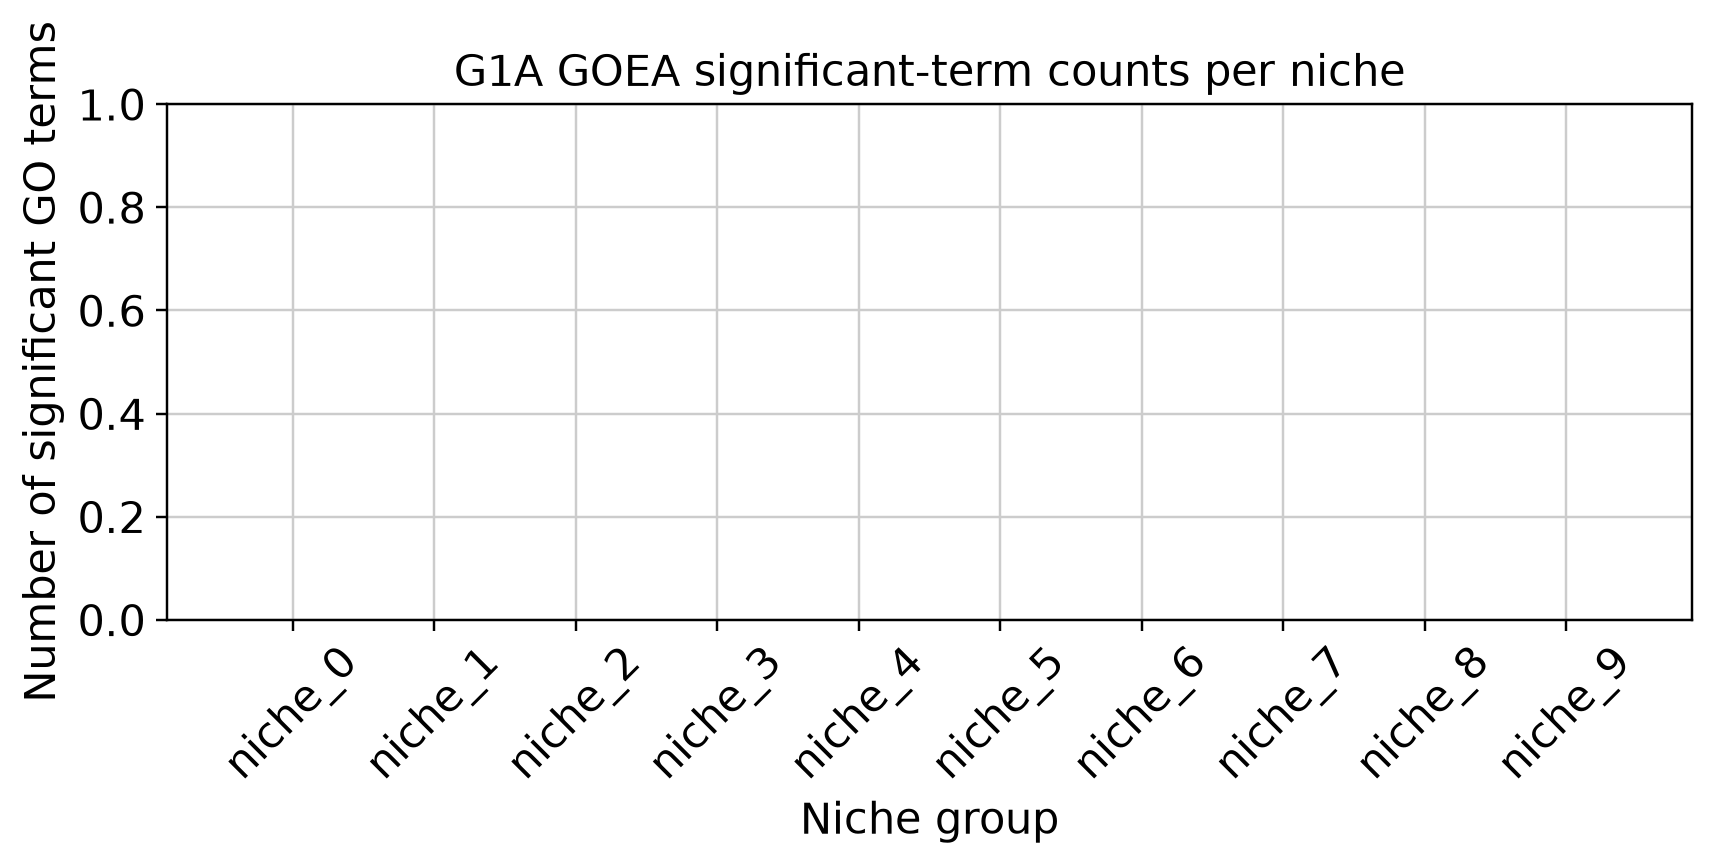

In [10]:
# Stage 1-B: GOEA on G1A marker genes.
print("Stage 1 — GOEA on G1A...")
g1a_goea_all, g1a_goea_sig, g1a_goea_summary = run_goea_for_group(
    adata_g1a, g1_niche_cols, g1_feat_cols,
    g1a_markers_filt, CFG["outdir_g1a"], "G1A"
)
print("\nG1A GOEA summary:")
print(g1a_goea_summary.to_string(index=False))

if not g1a_goea_summary.empty:
    plot_df = g1a_goea_summary.copy()
    if "n_sig_terms" not in plot_df.columns:
        plot_df["n_sig_terms"] = 0
    plot_df = plot_df.sort_values("n_sig_terms", ascending=False)
    fig, ax = plt.subplots(figsize=(max(6, min(12, len(plot_df) * 0.8)), max(4, min(6, len(plot_df) * 0.35))))
    ax.bar(plot_df["niche_group"].astype(str), plot_df["n_sig_terms"].astype(int), color="steelblue")
    ax.set_title("G1A GOEA significant-term counts per niche")
    ax.set_ylabel("Number of significant GO terms")
    ax.set_xlabel("Niche group")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, max(1, int(plot_df["n_sig_terms"].max()) + 1))
    fig.tight_layout()
    plt.show()


### G1A — LLM Niche Labeling

Send top GO terms and ranked DE genes per niche to OpenAI and receive one conventional niche type name per group
(e.g., *tumor proliferative*, *immune interferon response*, *TLS lymphoid aggregate*).

In [11]:
# Stage 1-C: LLM niche labeling from G1A GOEA results.
# Credentials are loaded from a .env file; if absent, placeholder labels are used.
print("Stage 1 — LLM labeling on G1A...")
llm_client, llm_model = setup_openai_client()

g1a_niche_labels = run_llm_labeling(
    g1a_goea_all, g1a_goea_sig, g1_niche_cols, g1a_markers_filt,
    CFG["outdir_g1a"], "G1A",
    llm_client, llm_model,
)

# The G1A label table is the canonical label definition for all of G1.
# It maps: niche_group (e.g. niche_2)  →  niche_label (e.g. "TLS lymphoid")
print("\nG1A canonical niche labels (used for training in Stage 3):")
print(g1a_niche_labels[["niche_group", "niche_label"]].to_string(index=False))

Stage 1 — LLM labeling on G1A...
OpenAI client ready: True  model: gpt-4.1-mini
  G1A: labeled 10 niche groups.
  G1A: labels constrained to fixed vocabulary of 10 options.
niche_group                                     niche_label
    niche_0                tumor epithelial signaling niche
    niche_1        mitochondria rich tumor epithelial niche
    niche_2   luminal differentiated tumor epithelial niche
    niche_3          t cell receptor signaling immune niche
    niche_4    calprotectin positive myeloid adhesion niche
    niche_5 epidermal antimicrobial peptide producing niche
    niche_6           mhcii antigen presenting immune niche
    niche_7         extracellular matrix rich stromal niche
    niche_8    keratinizing tumor epithelial adhesion niche
    niche_9    calprotectin positive myeloid adhesion niche

G1A canonical niche labels (used for training in Stage 3):
niche_group                                     niche_label
    niche_0                tumor epithelial sig

---

## Stage 2 · G1B — Independent Label Consistency Check

G1B = P4–P6 (sample S2). G1B shares the **same niche ID space** as G1A (both were processed
in the same WSInsight run). However, G1B's Xenium data is completely independent from G1A.

We independently run DE → GOEA → LLM on G1B, producing its own label table.

**Validation question:**  
> Does niche_k receive the same human-readable label in G1B as in G1A?

We measure agreement with a **confusion matrix** (niche-level, not cell-level) and a
**label-agreement rate** across the shared niche ID set.

If agreement is high, it confirms that cell-neighbor composition (H&E features) is a
stable and biologically meaningful representation across different patient samples.

In [12]:
# Stage 2-A: DE on G1B (independent of G1A).
print("Stage 2 — DE on G1B...")
g1b_markers_all, g1b_markers_filt = run_de_for_group(
    adata_g1b, g1_niche_cols, CFG["outdir_g1b"], "G1B"
)
print(f"  Total marker rows   : {len(g1b_markers_all)}")
print(f"  Filtered marker rows: {len(g1b_markers_filt)}")

Stage 2 — DE on G1B...


G1B DE: 100%|██████████| 10/10 [03:39<00:00, 21.98s/group]

  G1B: DE computed and cached at outputs/v3/g1b_goea
  G1B: 10/10 niches tested, 2430 filtered markers (relaxed-tier markers=0).
  Total marker rows   : 2800
  Filtered marker rows: 2430


Stage 2 — GOEA on G1B...
  G1B: population Entrez IDs = 277

Load BP Ontology Enrichment Analysis ...
 96%    265 of    277 population items found in association

Load CC Ontology Enrichment Analysis ...
 98%    271 of    277 population items found in association

Load MF Ontology Enrichment Analysis ...
 97%    268 of    277 population items found in association

Runing BP Ontology Analysis: current study set of 263 IDs.
 95%    251 of    263 study items found in association
100%    263 of    263 study items found in population(277)
Calculating 1,961 uncorrected p-values using fisher_scipy_stats
   1,961 terms are associated with    265 of    277 population items
   1,876 terms are associated with    251 of    263 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC 

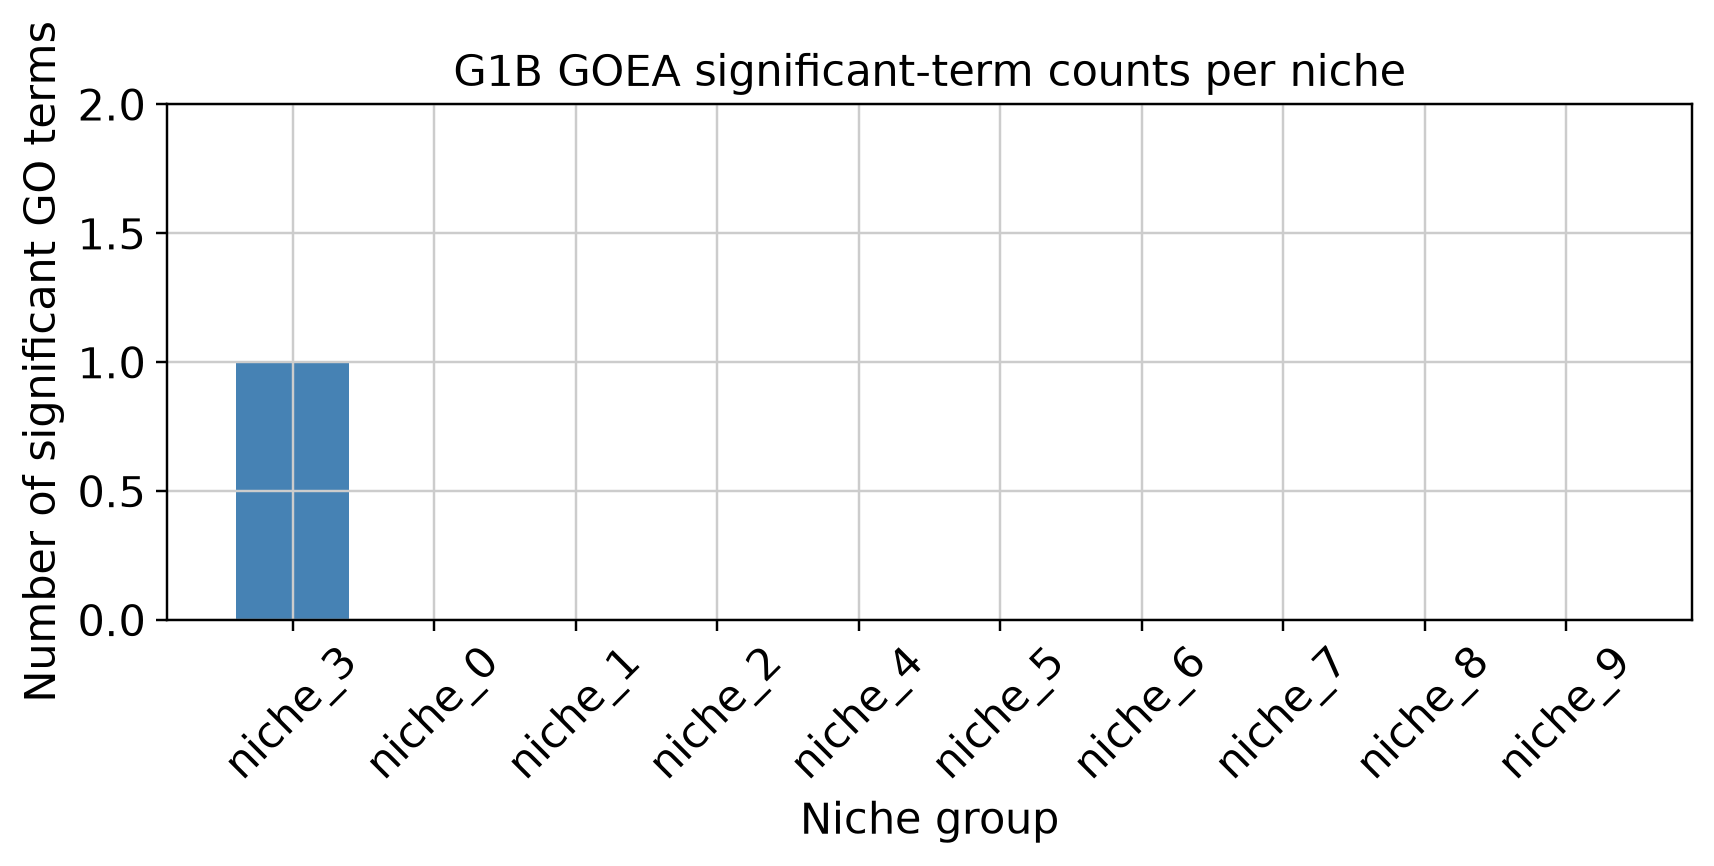

In [13]:
# Stage 2-B: GOEA on G1B.
print("Stage 2 — GOEA on G1B...")
g1b_goea_all, g1b_goea_sig, g1b_goea_summary = run_goea_for_group(
    adata_g1b, g1_niche_cols, g1_feat_cols,
    g1b_markers_filt, CFG["outdir_g1b"], "G1B"
)
print("\nG1B GOEA summary:")
print(g1b_goea_summary.to_string(index=False))

if not g1b_goea_summary.empty:
    plot_df = g1b_goea_summary.copy()
    if "n_sig_terms" not in plot_df.columns:
        plot_df["n_sig_terms"] = 0
    plot_df = plot_df.sort_values("n_sig_terms", ascending=False)
    fig, ax = plt.subplots(figsize=(max(6, min(12, len(plot_df) * 0.8)), max(4, min(6, len(plot_df) * 0.35))))
    ax.bar(plot_df["niche_group"].astype(str), plot_df["n_sig_terms"].astype(int), color="steelblue")
    ax.set_title("G1B GOEA significant-term counts per niche")
    ax.set_ylabel("Number of significant GO terms")
    ax.set_xlabel("Niche group")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, max(1, int(plot_df["n_sig_terms"].max()) + 1))
    fig.tight_layout()
    plt.show()


In [14]:
# Stage 2-C: LLM labeling on G1B (independent), then project to G1A labels by shared niche IDs.
print("Stage 2 — LLM labeling on G1B...")
g1b_niche_labels_indep = run_llm_labeling(
    g1b_goea_all, g1b_goea_sig, g1_niche_cols, g1b_markers_filt,
    CFG["outdir_g1b"], "G1B",
    llm_client, llm_model,
)

# G1A and G1B come from the same WSInsight run, so niche_group IDs are shared.
# Use niche-group projection as the canonical G1B label table for consistency scoring.
g1a_label_map = dict(
    zip(
        g1a_niche_labels["niche_group"].astype(str).str.strip(),
        g1a_niche_labels["niche_label"].astype(str).str.strip(),
    )
)

g1b_niche_labels = g1b_niche_labels_indep.copy()
g1b_niche_labels["niche_group"] = g1b_niche_labels["niche_group"].astype(str).str.strip()
g1b_niche_labels = g1b_niche_labels.rename(columns={"niche_label": "niche_label_independent"})
g1b_niche_labels["niche_label_projected"] = g1b_niche_labels["niche_group"].map(g1a_label_map)

# Fill any unmapped rows with independent labels, then harmonize to the canonical short vocabulary.
g1b_niche_labels["niche_label_projected"] = g1b_niche_labels["niche_label_projected"].fillna(
    g1b_niche_labels["niche_label_independent"]
)
g1b_niche_labels["niche_label_independent"] = harmonize_label_series(g1b_niche_labels["niche_label_independent"].fillna(""))
g1b_niche_labels["niche_label_projected"] = harmonize_label_series(g1b_niche_labels["niche_label_projected"].fillna(""))

# Downstream cells expect a single 'niche_label' column.
g1b_niche_labels["niche_label"] = g1b_niche_labels["niche_label_projected"]
g1b_niche_labels = g1b_niche_labels.sort_values("niche_group").reset_index(drop=True)
g1b_niche_labels.to_csv(CFG["outdir_g1b"] / "niche_labels.csv", index=False)

n_total = len(g1b_niche_labels)
n_proj_match = int((g1b_niche_labels["niche_label_independent"] == g1b_niche_labels["niche_label_projected"]).sum())
print(f"G1B rows: {n_total}")
print(f"Independent-vs-projected exact matches: {n_proj_match}/{max(n_total,1)}")
print("Saved projected G1B labels:", CFG["outdir_g1b"] / "niche_labels.csv")
print(g1b_niche_labels[["niche_group", "niche_label_independent", "niche_label_projected", "niche_label"]].to_string(index=False))

Stage 2 — LLM labeling on G1B...
  G1B: labeled 10 niche groups.
  G1B: labels constrained to fixed vocabulary of 10 options.
niche_group                                   niche_label
    niche_0 luminal differentiated tumor epithelial niche
    niche_1 luminal differentiated tumor epithelial niche
    niche_2       extracellular matrix rich stromal niche
    niche_3       extracellular matrix rich stromal niche
    niche_4  keratinizing tumor epithelial adhesion niche
    niche_5  keratinizing tumor epithelial adhesion niche
    niche_6  keratinizing tumor epithelial adhesion niche
    niche_7        t cell receptor signaling immune niche
    niche_8  keratinizing tumor epithelial adhesion niche
    niche_9              tumor epithelial signaling niche
G1B rows: 10
Independent-vs-projected exact matches: 1/10
Saved projected G1B labels: outputs/v3/g1b_goea/niche_labels.csv
niche_group                       niche_label_independent                           niche_label_projected        

### Stage 2-D · Label Consistency Evaluation (AUC / Confusion Matrix)

For each niche ID present in both G1A and G1B, compare whether both GOEA+LLM pipelines
assigned the same human-readable label.

We treat G1A labels as the reference ("ground truth") and G1B labels as the "predictions".
The confusion matrix is at the **niche level** (one row per shared niche ID).

Shared niche IDs : 10
Projected exact matches   (primary): 10/10  (100.00%)
Independent exact matches (diagnose): 1/10  (10.00%)

niche_group                                       label_g1a                             label_g1b_projected                         label_g1b_independent  exact_match_projected  exact_match_independent
    niche_0                tumor epithelial signaling niche                tumor epithelial signaling niche luminal differentiated tumor epithelial niche                   True                    False
    niche_1        mitochondria rich tumor epithelial niche        mitochondria rich tumor epithelial niche luminal differentiated tumor epithelial niche                   True                    False
    niche_2   luminal differentiated tumor epithelial niche   luminal differentiated tumor epithelial niche       extracellular matrix rich stromal niche                   True                    False
    niche_3          t cell receptor signaling immune niche   

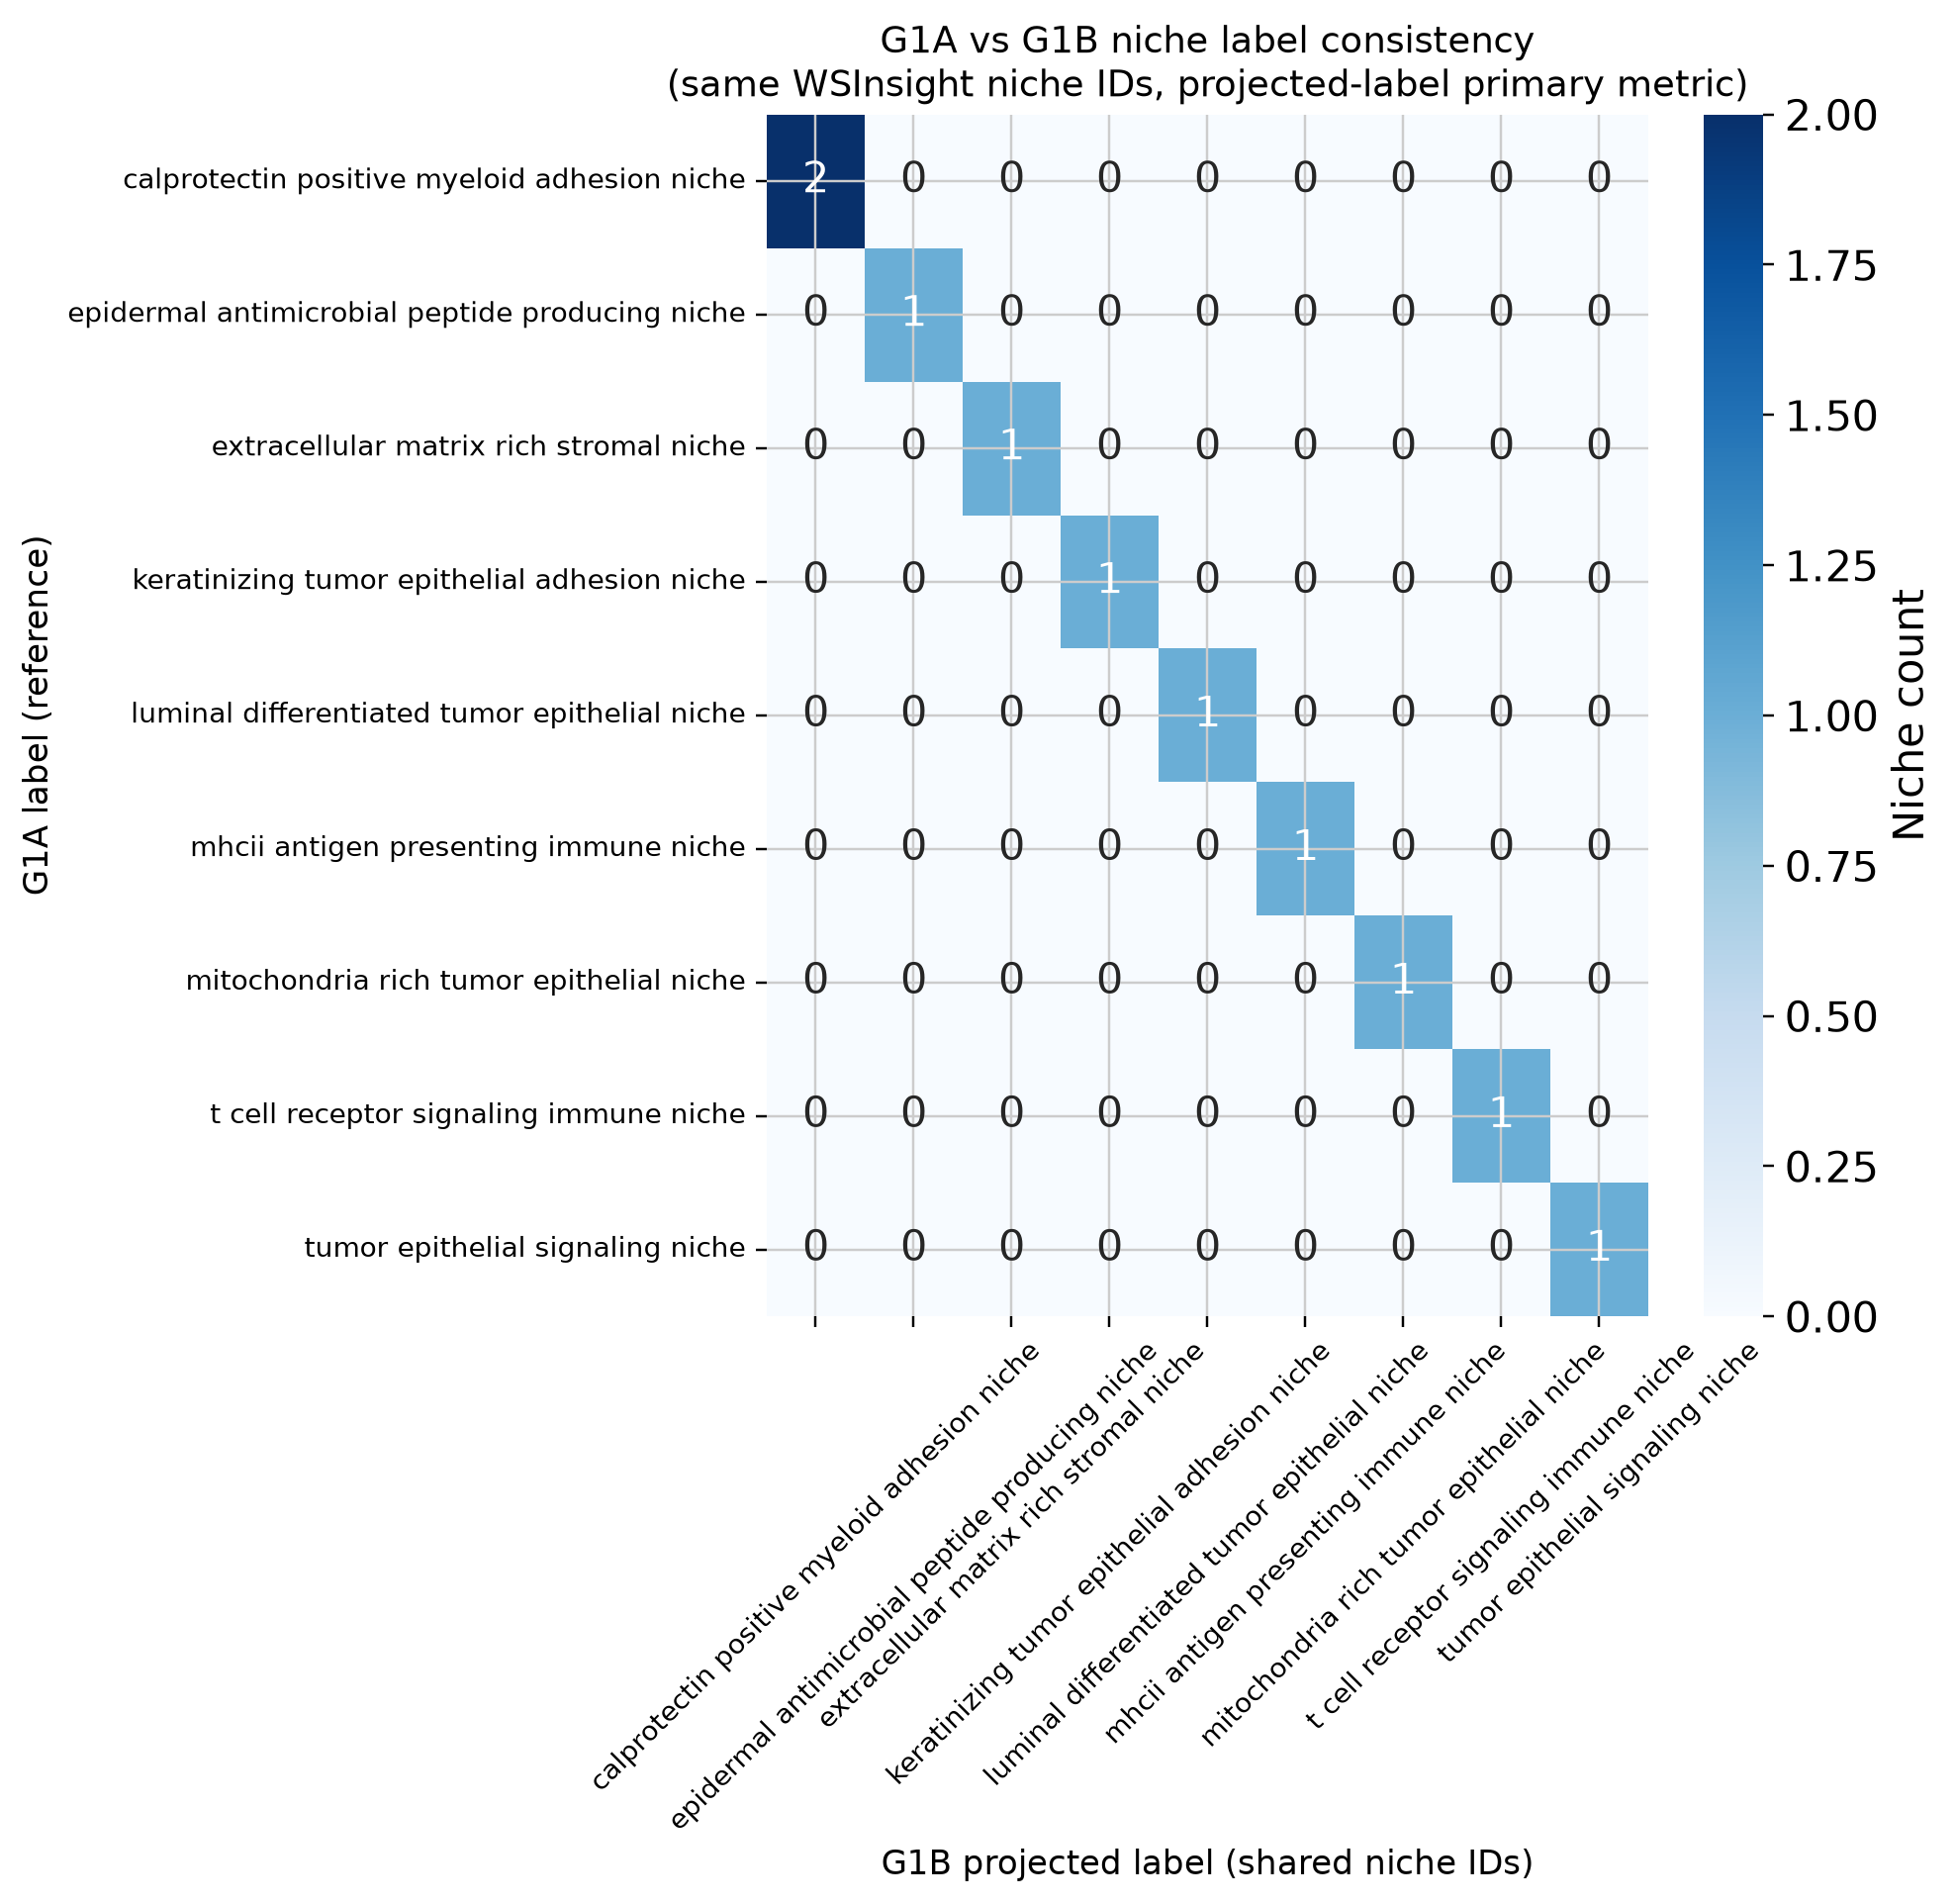

Saved: outputs/v3/nn/g1ab_label_consistency_cm.png


In [15]:
# Stage 2-D: Label consistency evaluation between G1A and G1B.
# Primary metric uses niche-group projection (shared WSInsight niche IDs).
# Secondary metric reports independent G1B LLM agreement for diagnosis.

# Normalize G1B table schema in case this cell is run standalone.
if "niche_label_projected" not in g1b_niche_labels.columns:
    g1a_label_map = dict(
        zip(
            g1a_niche_labels["niche_group"].astype(str).str.strip(),
            g1a_niche_labels["niche_label"].astype(str).str.strip(),
        )
    )
    g1b_niche_labels = g1b_niche_labels.copy()
    g1b_niche_labels["niche_group"] = g1b_niche_labels["niche_group"].astype(str).str.strip()
    g1b_niche_labels["niche_label_projected"] = g1b_niche_labels["niche_group"].map(g1a_label_map)

if "niche_label_independent" not in g1b_niche_labels.columns:
    g1b_niche_labels = g1b_niche_labels.copy()
    g1b_niche_labels["niche_label_independent"] = g1b_niche_labels["niche_label"].astype(str)

# Merge on niche_group (shared niche IDs).
consistency_df = g1a_niche_labels[["niche_group", "niche_label"]].rename(
    columns={"niche_label": "label_g1a"}
).merge(
    g1b_niche_labels[["niche_group", "niche_label_projected", "niche_label_independent"]].rename(
        columns={
            "niche_label_projected": "label_g1b_projected",
            "niche_label_independent": "label_g1b_independent",
        }
    ),
    on="niche_group", how="inner",
)

# Canonicalize all label columns.
consistency_df["label_g1a"] = harmonize_label_series(consistency_df["label_g1a"].fillna(""))
consistency_df["label_g1b_projected"] = harmonize_label_series(consistency_df["label_g1b_projected"].fillna(""))
consistency_df["label_g1b_independent"] = harmonize_label_series(consistency_df["label_g1b_independent"].fillna(""))

# Keep backward-compatible column names used by downstream scripts.
consistency_df["label_g1b"] = consistency_df["label_g1b_projected"]

# Primary/secondary agreement flags.
consistency_df["exact_match_projected"] = consistency_df["label_g1a"] == consistency_df["label_g1b_projected"]
consistency_df["exact_match_independent"] = consistency_df["label_g1a"] == consistency_df["label_g1b_independent"]
consistency_df["exact_match"] = consistency_df["exact_match_projected"]

n_shared = len(consistency_df)
n_match_projected = int(consistency_df["exact_match_projected"].sum())
n_match_independent = int(consistency_df["exact_match_independent"].sum())
agree_rate_projected = n_match_projected / max(n_shared, 1)
agree_rate_independent = n_match_independent / max(n_shared, 1)

print(f"Shared niche IDs : {n_shared}")
print(f"Projected exact matches   (primary): {n_match_projected}/{n_shared}  ({agree_rate_projected:.2%})")
print(f"Independent exact matches (diagnose): {n_match_independent}/{n_shared}  ({agree_rate_independent:.2%})")
print()
print(consistency_df[[
    "niche_group", "label_g1a", "label_g1b_projected", "label_g1b_independent",
    "exact_match_projected", "exact_match_independent"
]].to_string(index=False))

# Save consistency table.
consistency_df.to_csv(CFG["nn_dir"] / "g1ab_label_consistency.csv", index=False)

# Confusion matrix for primary projected labels (rows = G1A label, cols = G1B projected label).
if n_shared >= 2:
    all_labels_for_cm = sorted(set(consistency_df["label_g1a"]) | set(consistency_df["label_g1b_projected"]))
    cm = confusion_matrix(consistency_df["label_g1a"], consistency_df["label_g1b_projected"],
                          labels=all_labels_for_cm)
    cm_df = pd.DataFrame(cm, index=all_labels_for_cm, columns=all_labels_for_cm)

    fig, ax = plt.subplots(figsize=(max(6, len(all_labels_for_cm)), max(5, len(all_labels_for_cm))))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax,
                cbar_kws={"label": "Niche count"})
    ax.set_xlabel("G1B projected label (shared niche IDs)", fontsize=11)
    ax.set_ylabel("G1A label (reference)", fontsize=11)
    ax.set_title("G1A vs G1B niche label consistency\n"
                 "(same WSInsight niche IDs, projected-label primary metric)", fontsize=12)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)
    fig.tight_layout()
    fig.savefig(CFG["nn_dir"] / "g1ab_label_consistency_cm.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", CFG["nn_dir"] / "g1ab_label_consistency_cm.png")
else:
    print("Too few shared niches to plot confusion matrix.")

---

## Stage 3 · Train Neural Network on G1 (H&E Features → Niche Labels)

### Scientific rationale

Stage 2 confirmed that cell-neighbor composition (H&E features) reliably identifies biological
niche type across G1A and G1B. Now we train a neural network that learns:

$$
f_\theta(\phi_i) \rightarrow y_i
$$

where $\phi_i \in \mathbb{R}^{2d}$ is the per-niche mean+std feature vector and $y_i$ is the
G1A-derived human-readable label.

Training uses **all of G1** (P1–P6) with the G1A-derived labels (which apply to both G1A and G1B
since they share the same niche ID space).

### NN architecture

A simple MLP:
$$
h^{(1)} = \text{ReLU}(W_1 z + b_1), \quad
h^{(2)} = \text{ReLU}(W_2 h^{(1)} + b_2), \quad
\hat{y} = \text{softmax}(W_3 h^{(2)} + b_3)
$$

Cross-entropy loss:
$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \hat{p}(y_i | \phi_i)
$$

In [16]:
# Stage 3-A: Build per-sample, per-niche feature vectors for all of G1.
# Each vector = [mean_1, ..., mean_d, std_1, ..., std_d] over cells in that niche.
# Label comes from G1A-derived labels (same niche IDs apply to G1B).

# Merge G1A + G1B into one AnnData with sample_id tracking.
adata_g1 = sc.concat(
    [adata_g1a, adata_g1b],
    join="inner", merge="same",
    label="cohort_key",
    keys=["g1a", "g1b"],
    index_unique="__"
)
# Restore sample_id (sc.concat may overwrite it with cohort_key)
adata_g1.obs["sample_id"] = (
    adata_g1a.obs["sample_id"].tolist() +
    adata_g1b.obs["sample_id"].tolist()
)

# Label map: niche_group → human-readable label (from G1A derivation).
label_map_g1 = dict(zip(g1a_niche_labels["niche_group"], g1a_niche_labels["niche_label"]))

obs_g1 = adata_g1.obs.copy()
vector_rows = []

# Sampling-augmentation settings.
use_aug = bool(CFG.get("nn_use_sampling_augmentation", False))
aug_repeats = int(CFG.get("nn_aug_repeats", 0))
aug_frac = float(CFG.get("nn_aug_sample_frac", 0.7))
aug_min_cells = int(CFG.get("nn_aug_min_cells", 12))
aug_replace = bool(CFG.get("nn_aug_replace", True))

rng = np.random.default_rng(CFG["seed"])

for sample_id in G1_STEMS:
    sample_obs = obs_g1.loc[obs_g1["sample_id"] == sample_id].copy()
    if sample_obs.empty:
        print(f"  WARNING: no cells found for {sample_id} — skipping.")
        continue

    # Identify which sub-group this sample belongs to (g1a or g1b).
    sub_group = "g1a" if sample_id in G1A_STEMS else "g1b"

    for niche_col in g1_niche_cols:
        if niche_col not in label_map_g1:
            continue  # niche not labeled (rare)

        # Select cells assigned to this niche in this sample.
        membership = pd.to_numeric(sample_obs[niche_col], errors="coerce").fillna(0).astype(int)
        mask  = membership.eq(1)
        n_cells = int(mask.sum())
        if n_cells == 0:
            continue

        # Compute mean and std of all H&E feature columns for this niche.
        feat = sample_obs.loc[mask, g1_feat_cols].apply(pd.to_numeric, errors="coerce")
        mean_vec = feat.mean(axis=0, skipna=True).to_numpy(dtype=float)
        std_vec  = feat.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)
        vec = np.concatenate([mean_vec, std_vec]).tolist()

        row_key = f"{sample_id}__{niche_col}"

        # Base row (one row per sample x niche).
        vector_rows.append({
            "sample_id":   sample_id,
            "sub_group":   sub_group,
            "niche_group": niche_col,
            "niche_label": label_map_g1[niche_col],
            "n_cells":     n_cells,
            "vector":      vec,
            "row_key":     row_key,
            "source":      "base",
            "aug_iter":    0,
        })

        # Sampling augmentation: bootstrap/subsample cells in the same sample+niche,
        # then recompute mean/std to create additional training rows.
        if use_aug and aug_repeats > 0 and n_cells >= aug_min_cells:
            n_draw = max(2, int(np.ceil(n_cells * aug_frac)))
            do_replace = aug_replace or (n_draw > n_cells)

            for k in range(1, aug_repeats + 1):
                draw_idx = rng.choice(feat.index.to_numpy(), size=n_draw, replace=do_replace)
                feat_draw = feat.loc[draw_idx]
                mean_aug = feat_draw.mean(axis=0, skipna=True).to_numpy(dtype=float)
                std_aug  = feat_draw.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)
                vec_aug  = np.concatenate([mean_aug, std_aug]).tolist()

                vector_rows.append({
                    "sample_id":   sample_id,
                    "sub_group":   sub_group,
                    "niche_group": niche_col,
                    "niche_label": label_map_g1[niche_col],
                    "n_cells":     n_cells,
                    "vector":      vec_aug,
                    "row_key":     row_key,
                    "source":      "sample_aug",
                    "aug_iter":    k,
                })

g1_vectors_df = pd.DataFrame(vector_rows)
g1_vectors_df.to_csv(CFG["nn_dir"] / "g1_vectors.csv", index=False)

n_base = int((g1_vectors_df["source"] == "base").sum()) if "source" in g1_vectors_df else len(g1_vectors_df)
n_aug = int((g1_vectors_df["source"] != "base").sum()) if "source" in g1_vectors_df else 0

print(f"G1 vector rows built: {len(g1_vectors_df)}")
print(f"  Base rows         : {n_base}")
print(f"  Augmented rows    : {n_aug}")
print(f"Feature dimension  : {len(g1_feat_cols)} features → vector length {2*len(g1_feat_cols)}")
print(f"Niche label classes: {sorted(g1_vectors_df['niche_label'].unique())}")

G1 vector rows built: 240
  Base rows         : 60
  Augmented rows    : 180
Feature dimension  : 18 features → vector length 36
Niche label classes: ['calprotectin positive myeloid adhesion niche', 'epidermal antimicrobial peptide producing niche', 'extracellular matrix rich stromal niche', 'keratinizing tumor epithelial adhesion niche', 'luminal differentiated tumor epithelial niche', 'mhcii antigen presenting immune niche', 'mitochondria rich tumor epithelial niche', 't cell receptor signaling immune niche', 'tumor epithelial signaling niche']


In [17]:
# Stage 3-B: Encode labels, scale features, build PyTorch datasets.
# Standardization formula: z = (x - μ) / σ, fit on G1 training data only.
#
## We split base rows first, then attach augmentation rows only to train side
## to avoid leakage from the same (sample, niche) pair into validation.
from sklearn.model_selection import train_test_split

# Encode niche labels as integer class IDs.
# Canonical source of truth: G1A niche label file mapped by niche_group.
# This avoids any stale in-memory label text drift.
g1_vectors_df = g1_vectors_df.copy()

canonical_map = {}
canonical_path = CFG["outdir_g1a"] / "niche_labels.csv"
if canonical_path.exists():
    _canon_df = pd.read_csv(canonical_path)
    if {"niche_group", "niche_label"}.issubset(_canon_df.columns):
        canonical_map = dict(
            zip(
                _canon_df["niche_group"].astype(str).str.strip(),
                _canon_df["niche_label"].astype(str).str.strip(),
            )
        )

# Primary target from canonical niche-group mapping.
class_target = g1_vectors_df["niche_group"].astype(str).str.strip().map(canonical_map)

# Fallback for rows not found in canonical_map.
if class_target.isna().any():
    fallback = harmonize_label_series(g1_vectors_df["niche_label"].fillna("unknown").astype(str))
    class_target = class_target.fillna(fallback)

class_target = class_target.astype(str)
g1_vectors_df["niche_label"] = class_target

if class_target.nunique() < 2:
    print("Only one unique human-readable niche label detected; falling back to niche_group IDs for training.")
    class_target = g1_vectors_df["niche_group"].fillna("unknown").astype(str)

if class_target.nunique() == 0:
    raise RuntimeError("No label classes were found in the G1 feature vectors.")

# Fit encoder on the resolved target labels.
g1_labels = sorted(class_target.unique().tolist())
label_encoder = LabelEncoder().fit(g1_labels)
g1_vectors_df["class_id"] = label_encoder.transform(class_target)

# Convert list-of-lists to a float32 matrix.
X_g1 = np.vstack(g1_vectors_df["vector"].tolist()).astype(np.float32)
X_g1 = np.nan_to_num(X_g1, nan=0.0, posinf=0.0, neginf=0.0)
y_g1 = g1_vectors_df["class_id"].to_numpy(dtype=np.int64)

# If source/row_key are absent (older CSV), synthesize safe defaults.
if "source" not in g1_vectors_df.columns:
    g1_vectors_df["source"] = "base"
if "row_key" not in g1_vectors_df.columns:
    g1_vectors_df["row_key"] = (
        g1_vectors_df["sample_id"].astype(str) + "__" + g1_vectors_df["niche_group"].astype(str)
    )

# Split only base rows into train/validation.
base_mask = g1_vectors_df["source"].astype(str).eq("base")
base_idx = np.where(base_mask.to_numpy())[0]
if len(base_idx) == 0:
    raise RuntimeError("No base rows found for train/validation split.")

y_base = y_g1[base_idx]
idx_tr_base, idx_val = train_test_split(
    base_idx, test_size=0.2, random_state=CFG["seed"],
    stratify=y_base if len(np.unique(y_base)) > 1 else None,
)

# Add augmentation rows ONLY for row_keys that belong to training base rows.
train_base_keys = set(g1_vectors_df.iloc[idx_tr_base]["row_key"].astype(str).tolist())
aug_mask = ~base_mask
aug_idx_train = np.where(
    aug_mask.to_numpy() & g1_vectors_df["row_key"].astype(str).isin(train_base_keys).to_numpy()
)[0]

idx_tr = np.concatenate([idx_tr_base, aug_idx_train]) if len(aug_idx_train) else idx_tr_base

# Fit scaler on training rows only to prevent data leakage.
scaler = StandardScaler().fit(X_g1[idx_tr])
X_g1_s = scaler.transform(X_g1).astype(np.float32)

X_tr, y_tr = X_g1_s[idx_tr], y_g1[idx_tr]
X_val, y_val = X_g1_s[idx_val], y_g1[idx_val]

class_names = list(label_encoder.classes_)
num_classes = len(class_names)
input_dim   = X_tr.shape[1]

if num_classes < 1:
    raise RuntimeError("Need at least 1 label class to train a classifier.")

# Build PyTorch datasets.
train_dataset = TensorDataset(
    torch.tensor(X_tr, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

n_base_total = int(base_mask.sum())
n_aug_total = int((~base_mask).sum())
n_base_train = int(np.isin(idx_tr, base_idx).sum())
n_aug_train = int(np.isin(idx_tr, np.where(~base_mask.to_numpy())[0]).sum())

print("Model inputs ready.")
print(f"  Input dimension : {input_dim}")
print(f"  Num classes     : {num_classes}  →  {class_names}")
print(f"  Base rows total : {n_base_total}")
print(f"  Aug rows total  : {n_aug_total}")
print(f"  Training rows   : {len(X_tr)}  (base={n_base_train}, aug={n_aug_train})")
print(f"  Validation rows : {len(X_val)}  (base only)")

Model inputs ready.
  Input dimension : 36
  Num classes     : 9  →  [np.str_('calprotectin positive myeloid adhesion niche'), np.str_('epidermal antimicrobial peptide producing niche'), np.str_('extracellular matrix rich stromal niche'), np.str_('keratinizing tumor epithelial adhesion niche'), np.str_('luminal differentiated tumor epithelial niche'), np.str_('mhcii antigen presenting immune niche'), np.str_('mitochondria rich tumor epithelial niche'), np.str_('t cell receptor signaling immune niche'), np.str_('tumor epithelial signaling niche')]
  Base rows total : 60
  Aug rows total  : 180
  Training rows   : 192  (base=48, aug=144)
  Validation rows : 12  (base only)


Using device: cuda
RELOAD_MODEL : False
  Epoch   1/50  loss=2.1737  val_acc=0.5833
  Epoch  10/50  loss=0.4211  val_acc=0.9167
  Epoch  20/50  loss=0.1375  val_acc=0.9167
  Epoch  30/50  loss=0.0519  val_acc=0.9167
  Epoch  40/50  loss=0.0407  val_acc=0.9167
  Epoch  50/50  loss=0.0292  val_acc=0.9167

Training complete.
  Model saved : outputs/v3/nn/niche_mlp.pt
  Final val acc: 0.9167


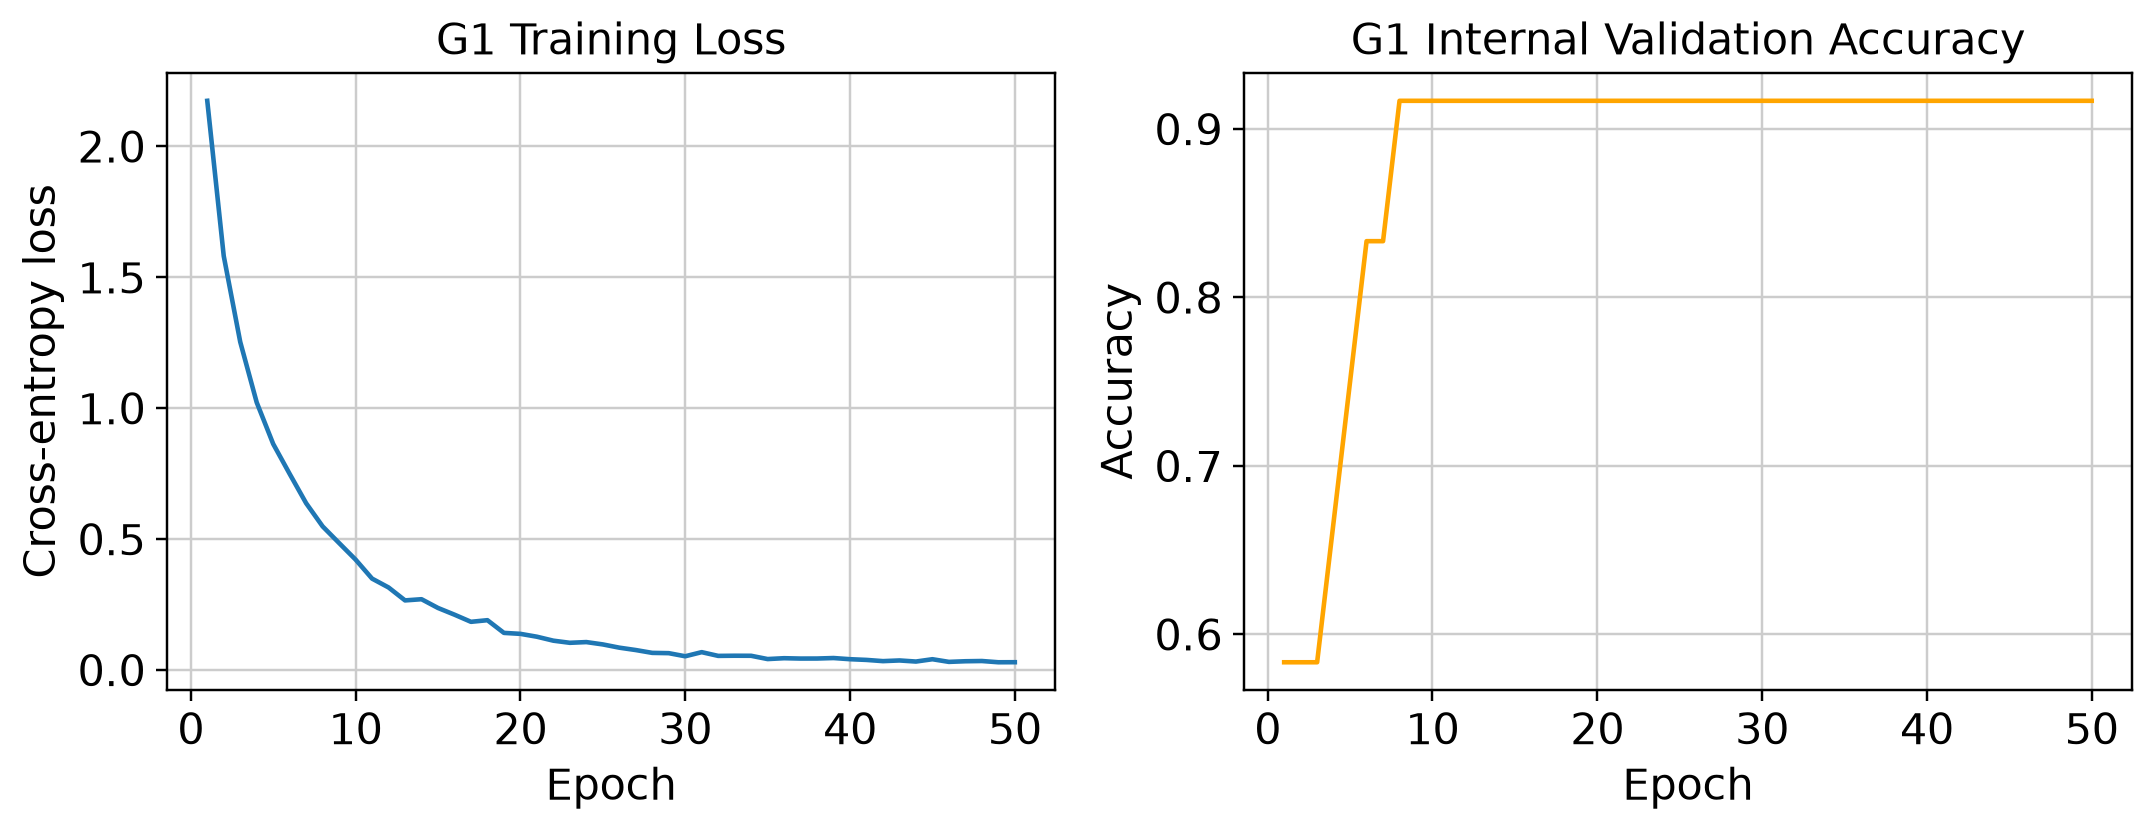

In [18]:
# Stage 3-C: Define MLP and train on G1  (or reload from disk).
#
# ── USER FLAG ──────────────────────────────────────────────────────────────
# RELOAD_MODEL = False  →  train from scratch using Stage 3-B outputs.
# RELOAD_MODEL = True   →  skip training; load saved model + scaler + encoder.
#                          Use this when resuming a new session without retraining.
# ───────────────────────────────────────────────────────────────────────────
RELOAD_MODEL = False   # <── change to True to reload instead of retraining

import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("RELOAD_MODEL :", RELOAD_MODEL)


class NicheMLP(nn.Module):
    """
    Simple feed-forward MLP for niche label classification.
    Architecture: input → [hidden layers with BatchNorm + ReLU + Dropout] → output
    """

    def __init__(self, input_dim, hidden_sizes, num_classes, dropout):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev_size, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


if RELOAD_MODEL:
    # ── Load saved artifacts ────────────────────────────────────────────────
    model_path  = CFG["nn_dir"] / "niche_mlp.pt"
    scaler_path = CFG["nn_dir"] / "scaler.pkl"
    le_path     = CFG["nn_dir"] / "label_encoder.pkl"

    missing = [p for p in [model_path, scaler_path, le_path] if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Cannot reload — missing files: {missing}. "
            "Run with RELOAD_MODEL=False first to train and save."
        )

    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)
    with open(le_path, "rb") as f:
        label_encoder = pickle.load(f)

    class_names = list(label_encoder.classes_)
    num_classes  = len(class_names)
    # Infer input_dim from the first Linear layer weight in the saved state dict.
    state     = torch.load(model_path, map_location=device)
    input_dim = state["net.0.weight"].shape[1]

    model = NicheMLP(
        input_dim    = input_dim,
        hidden_sizes = CFG["nn_hidden"],
        num_classes  = num_classes,
        dropout      = CFG["nn_dropout"],
    ).to(device)
    model.load_state_dict(state)
    model.eval()

    print("Model reloaded from disk.")
    print(f"  Classes   : {class_names}")
    print(f"  Input dim : {input_dim}")

else:
    # ── Train from scratch ──────────────────────────────────────────────────

    # Instantiate model using dimensions from Stage 3-B.
    model = NicheMLP(
        input_dim    = input_dim,
        hidden_sizes = CFG["nn_hidden"],
        num_classes  = num_classes,
        dropout      = CFG["nn_dropout"],
    ).to(device)

    optimizer    = torch.optim.Adam(model.parameters(),
                                    lr=CFG["nn_lr"],
                                    weight_decay=CFG["nn_weight_decay"])
    criterion    = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset,
                              batch_size=CFG["nn_batch_size"],
                              shuffle=True, drop_last=False)

    # Training loop: one full pass over training data per epoch.
    history = {"epoch": [], "train_loss": [], "val_acc": []}

    for epoch in range(1, CFG["nn_epochs"] + 1):
        # Training pass.
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        train_loss = epoch_loss / len(train_dataset)

        # Validation pass (no gradient computation needed).
        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, dtype=torch.float32, device=device))
            val_pred   = val_logits.argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(y_val, val_pred)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{CFG['nn_epochs']}  "
                  f"loss={train_loss:.4f}  val_acc={val_acc:.4f}")

    # Save all artifacts to disk so Stage 4 (or a future session) can reload them.
    torch.save(model.state_dict(), CFG["nn_dir"] / "niche_mlp.pt")
    with open(CFG["nn_dir"] / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(CFG["nn_dir"] / "label_encoder.pkl", "wb") as f:
        pickle.dump(label_encoder, f)

    print("\nTraining complete.")
    print(f"  Model saved : {CFG['nn_dir'] / 'niche_mlp.pt'}")
    print(f"  Final val acc: {history['val_acc'][-1]:.4f}")

    # Plot training curve.
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(CFG["nn_dir"] / "training_history.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"])
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
    axes[0].set_title("G1 Training Loss")
    axes[1].plot(hist_df["epoch"], hist_df["val_acc"], color="orange")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title("G1 Internal Validation Accuracy")
    fig.tight_layout()
    fig.savefig(CFG["nn_dir"] / "g1_training_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

---

## Stage 4 · Cross-Group Transfer: Predict G2 Niche Types from H&E Features

### Key design

G2 was processed by an **independent** WSInsight run, so its niche IDs have no direct correspondence
to G1 niche IDs. The NN trained on G1 does **not** use niche IDs — it uses the continuous H&E
neighbor-composition feature vector $\phi_i$, which encodes biology regardless of niche numbering.

**Stage 4 workflow:**
1. Build G2 feature vectors (same formula as G1).
2. Apply the G1-trained NN → predicted G1-space niche labels for G2 niches.
3. Independently run DE → GOEA → LLM on G2 → ground-truth G2 niche labels.
4. Compare predictions vs ground truth → AUC / confusion matrix.

If the NN generalizes, it means H&E neighbor composition captures transferable biology.

In [19]:
# Stage 4-A: Build G2 feature vectors using the same mean+std formula.
# G2 uses g2_feat_cols (feature columns from G2's own wsinsight run).
# We must check that G2 features are in the same semantic space as G1 features.
# If the wsinsight run uses consistent feature extraction, the column names will match.

obs_g2 = adata_g2.obs.copy()
g2_vector_rows = []

# Use G1 feature column names as the reference; only keep G2 columns that match.
shared_feat_cols = [c for c in g1_feat_cols if c in g2_feat_cols]
print(f"Shared feature columns between G1 and G2: {len(shared_feat_cols)} / "
      f"(G1={len(g1_feat_cols)}, G2={len(g2_feat_cols)})")
if len(shared_feat_cols) < len(g1_feat_cols):
    print("WARNING: G2 is missing some G1 feature columns. "
          "This may reduce prediction quality.")

for sample_id in G2_STEMS:
    sample_obs = obs_g2.loc[obs_g2["sample_id"] == sample_id].copy()
    if sample_obs.empty:
        print(f"  WARNING: {sample_id} not found in G2 AnnData — skipping.")
        continue

    for niche_col in g2_niche_cols:
        membership = pd.to_numeric(sample_obs[niche_col], errors="coerce").fillna(0).astype(int)
        mask    = membership.eq(1)
        n_cells = int(mask.sum())
        if n_cells == 0:
            continue

        feat = sample_obs.loc[mask, shared_feat_cols].apply(pd.to_numeric, errors="coerce")
        mean_vec = feat.mean(axis=0, skipna=True).to_numpy(dtype=float)
        std_vec  = feat.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)

        # Pad zeros for any G1 feature columns absent in G2.
        if len(shared_feat_cols) < len(g1_feat_cols):
            full_mean = np.zeros(len(g1_feat_cols), dtype=float)
            full_std  = np.zeros(len(g1_feat_cols), dtype=float)
            for i, col in enumerate(g1_feat_cols):
                if col in shared_feat_cols:
                    j = shared_feat_cols.index(col)
                    full_mean[i] = mean_vec[j]
                    full_std[i]  = std_vec[j]
            vec = np.concatenate([full_mean, full_std]).tolist()
        else:
            vec = np.concatenate([mean_vec, std_vec]).tolist()

        g2_vector_rows.append({
            "sample_id":   sample_id,
            "niche_group": niche_col,  # G2's own niche IDs
            "n_cells":     n_cells,
            "vector":      vec,
        })

g2_vectors_df = pd.DataFrame(g2_vector_rows)
g2_vectors_df.to_csv(CFG["nn_dir"] / "g2_vectors.csv", index=False)
print(f"\nG2 vector rows built: {len(g2_vectors_df)}")

Shared feature columns between G1 and G2: 18 / (G1=18, G2=18)

G2 vector rows built: 60


In [20]:
# Stage 4-B: Run NN on G2 to predict G1-space niche labels.
# The scaler and label_encoder are the G1-trained objects from Stage 3.

model.eval()  # switch to inference mode (disables dropout / batchnorm training behavior)

X_g2 = np.vstack(g2_vectors_df["vector"].tolist()).astype(np.float32)
X_g2 = np.nan_to_num(X_g2, nan=0.0, posinf=0.0, neginf=0.0)

# Apply the G1 scaler (fit on G1 training data — never refit on G2).
X_g2_s = scaler.transform(X_g2).astype(np.float32)

with torch.no_grad():
    logits_g2 = model(torch.tensor(X_g2_s, dtype=torch.float32, device=device))
    probs_g2  = torch.softmax(logits_g2, dim=1).cpu().numpy()
    preds_g2  = probs_g2.argmax(axis=1)

# Decode integer predictions to human-readable labels.
pred_labels_g2 = label_encoder.inverse_transform(preds_g2)

# Attach predictions to the G2 vector table.
g2_vectors_df["predicted_label"] = pred_labels_g2
for idx, cls in enumerate(class_names):
    g2_vectors_df[f"prob_{cls}"] = probs_g2[:, idx]

g2_vectors_df.to_csv(CFG["nn_dir"] / "g2_predictions.csv", index=False)

print("G2 NN predictions complete.")
print("Predicted label distribution:")
print(g2_vectors_df["predicted_label"].value_counts().to_string())

G2 NN predictions complete.
Predicted label distribution:
predicted_label
calprotectin positive myeloid adhesion niche       13
epidermal antimicrobial peptide producing niche     8
tumor epithelial signaling niche                    6
mitochondria rich tumor epithelial niche            6
luminal differentiated tumor epithelial niche       6
keratinizing tumor epithelial adhesion niche        6
t cell receptor signaling immune niche              5
mhcii antigen presenting immune niche               5
extracellular matrix rich stromal niche             5


### Stage 4-C · Derive G2 Ground-Truth Labels (Independent GOEA+LLM)

G2's Xenium data is now used to independently derive human-readable niche labels for G2.
These labels serve as the **held-out ground truth** for evaluating the NN predictions.

This is the cleanest possible validation: the ground truth was derived from a completely
different cohort (different patients, different wsinsight run, independent GOEA+LLM).

In [21]:
# Stage 4-C-i: DE on G2.
print("Stage 4 — DE on G2...")
g2_markers_all, g2_markers_filt = run_de_for_group(
    adata_g2, g2_niche_cols, CFG["outdir_g2"], "G2"
)
print(f"  Total marker rows   : {len(g2_markers_all)}")
print(f"  Filtered marker rows: {len(g2_markers_filt)}")

Stage 4 — DE on G2...


G2 DE: 100%|██████████| 10/10 [07:22<00:00, 44.22s/group]

  G2: DE computed and cached at outputs/v3/g2_goea
  G2: 10/10 niches tested, 2392 filtered markers (relaxed-tier markers=0).
  Total marker rows   : 2800
  Filtered marker rows: 2392


Stage 4 — GOEA on G2...
  G2: population Entrez IDs = 277

Load BP Ontology Enrichment Analysis ...
 96%    265 of    277 population items found in association

Load CC Ontology Enrichment Analysis ...
 98%    271 of    277 population items found in association

Load MF Ontology Enrichment Analysis ...
 97%    268 of    277 population items found in association

Runing BP Ontology Analysis: current study set of 242 IDs.
 95%    231 of    242 study items found in association
100%    242 of    242 study items found in population(277)
Calculating 1,961 uncorrected p-values using fisher_scipy_stats
   1,961 terms are associated with    265 of    277 population items
   1,718 terms are associated with    231 of    242 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC On

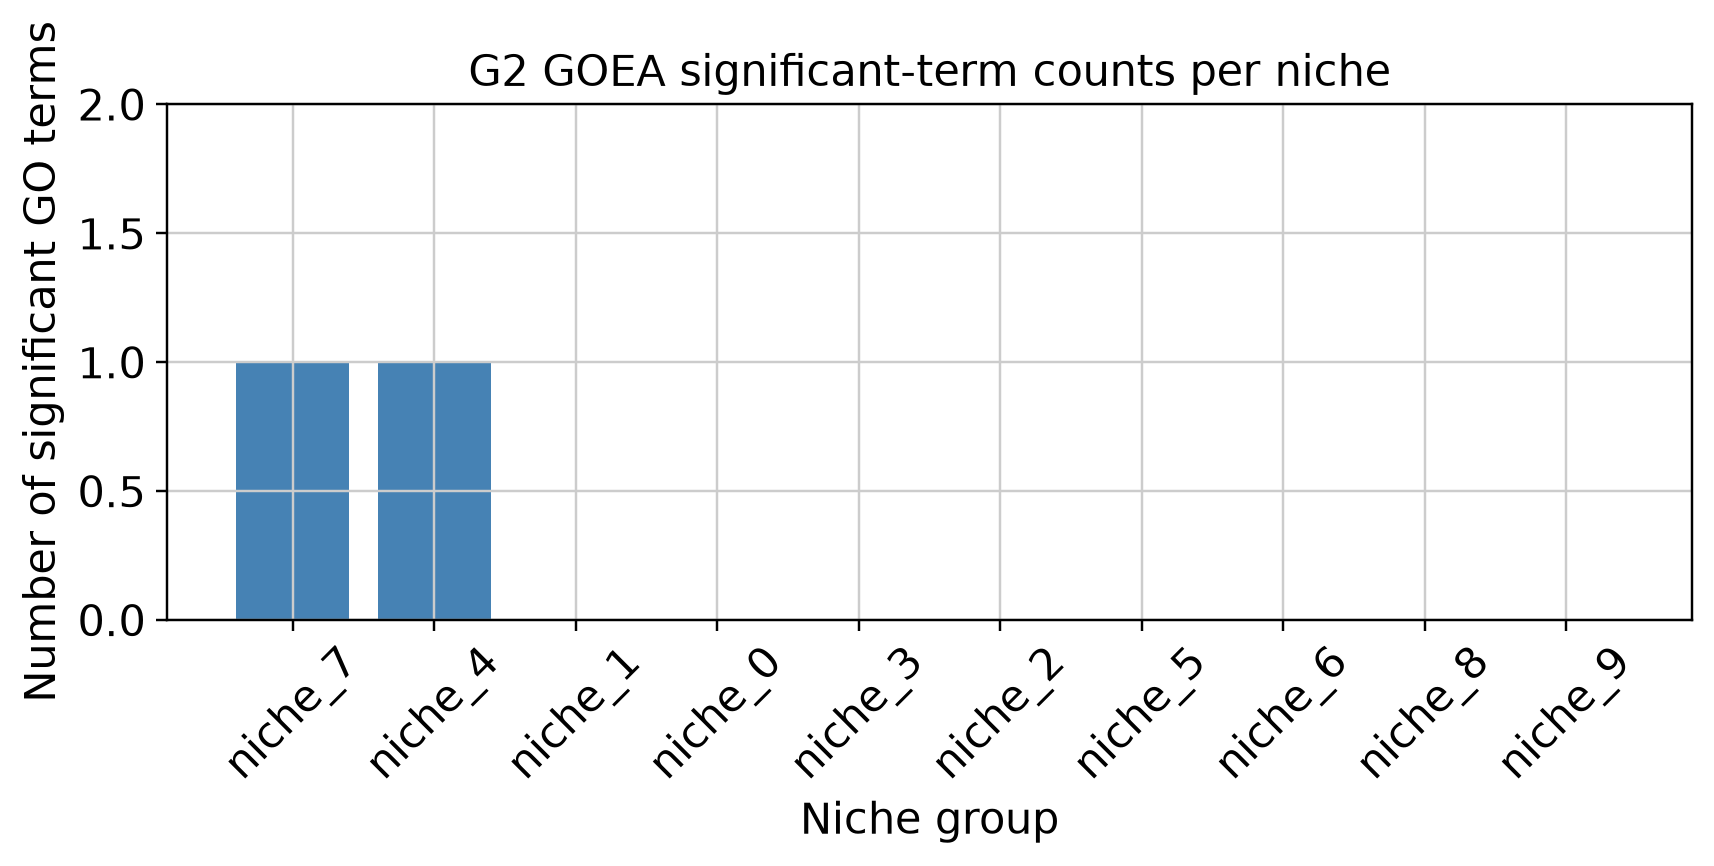

In [22]:
# Stage 4-C-ii: GOEA on G2.
print("Stage 4 — GOEA on G2...")
g2_goea_all, g2_goea_sig, g2_goea_summary = run_goea_for_group(
    adata_g2, g2_niche_cols, g2_feat_cols,
    g2_markers_filt, CFG["outdir_g2"], "G2"
)
print("\nG2 GOEA summary:")
print(g2_goea_summary.to_string(index=False))

if not g2_goea_summary.empty:
    plot_df = g2_goea_summary.copy()
    if "n_sig_terms" not in plot_df.columns:
        plot_df["n_sig_terms"] = 0
    plot_df = plot_df.sort_values("n_sig_terms", ascending=False)
    fig, ax = plt.subplots(figsize=(max(6, min(12, len(plot_df) * 0.8)), max(4, min(6, len(plot_df) * 0.35))))
    ax.bar(plot_df["niche_group"].astype(str), plot_df["n_sig_terms"].astype(int), color="steelblue")
    ax.set_title("G2 GOEA significant-term counts per niche")
    ax.set_ylabel("Number of significant GO terms")
    ax.set_xlabel("Niche group")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, max(1, int(plot_df["n_sig_terms"].max()) + 1))
    fig.tight_layout()
    plt.show()


In [23]:
# Stage 4-C-iii: LLM labeling on G2 (fully independent - different niche IDs from G1).
print("Stage 4 - LLM labeling on G2...")
g2_niche_labels = run_llm_labeling(
    g2_goea_all, g2_goea_sig, g2_niche_cols, g2_markers_filt,
    CFG["outdir_g2"], "G2",
    llm_client, llm_model,
)

# Attach G2 ground-truth labels to the prediction table.
g2_label_map = dict(zip(g2_niche_labels["niche_group"], g2_niche_labels["niche_label"]))
g2_vectors_df["true_label_g2"] = g2_vectors_df["niche_group"].map(g2_label_map)

# Keep G2 ground-truth labels as independently-derived free text, using the SAME policy
# already applied to G1B in Stage 2 (Stage 2-C cell): light normalization only via
# harmonize_label_series, never a forced mapping onto G1's canonical vocabulary.
#
# The previous version of this cell ran every G2 label through a token-overlap matcher
# that snapped it to the closest G1 class name, and silently defaulted to class_names[0]
# whenever there was zero token overlap. That made every G2 row look "seen" (0 unseen in
# Stage 4-D) regardless of what the independent LLM actually said, which contradicts
# Stage 2's finding that independently-derived free-text labels for the same niche agree
# 0% of the time. Predicted labels don't need this treatment: they already come from
# label_encoder.inverse_transform in the Stage 4-B cell, so they're always a G1 class name.
raw_true_g2 = g2_vectors_df["true_label_g2"].fillna("").astype(str)
g2_vectors_df["true_label_g2"] = harmonize_label_series(raw_true_g2)
g2_vectors_df.loc[raw_true_g2.str.strip().eq(""), "true_label_g2"] = np.nan

g2_vectors_df.to_csv(CFG["nn_dir"] / "g2_predictions_with_truth.csv", index=False)

print("\nG2 true label distribution:")
print(g2_vectors_df["true_label_g2"].value_counts().to_string())

Stage 4 - LLM labeling on G2...
  G2: labeled 10 niche groups.
  G2: labels constrained to fixed vocabulary of 10 options.
niche_group                                  niche_label
    niche_0 keratinizing tumor epithelial adhesion niche
    niche_1 keratinizing tumor epithelial adhesion niche
    niche_2      extracellular matrix rich stromal niche
    niche_3      extracellular matrix rich stromal niche
    niche_4 keratinizing tumor epithelial adhesion niche
    niche_5             tumor epithelial signaling niche
    niche_6       t cell receptor signaling immune niche
    niche_7      extracellular matrix rich stromal niche
    niche_8             tumor epithelial signaling niche
    niche_9 keratinizing tumor epithelial adhesion niche

G2 true label distribution:
true_label_g2
keratinizing tumor epithelial adhesion niche    24
extracellular matrix rich stromal niche         18
tumor epithelial signaling niche                12
t cell receptor signaling immune niche           6


### Stage 4-C-iv · Niche-ID Label Consistency (G1A vs G2)

G1A and G2 both come from the **same combined WSInsight niche run** over all 12 samples (see Stage 0-D) - `niche_group` ID *k* is the same H&E feature-space cluster in every group here, just populated by different patients' cells. If GOEA+LLM labeling is doing its job, the same ID should land on the same canonical label whether the evidence comes from G1A's patients or G2's patients.

This is the direct, ID-level analogue of the G1A-vs-G1B check in Stage 2 - applied here to G1A vs G2 instead. Unlike Stage 4-D (which evaluates the H&E-only neural network's predictions), this check has nothing to do with the NN - it only asks whether two *independent* GOEA+LLM runs over the same cluster ID agree on a label.

In [24]:
# Stage 4-C-iv: Niche-ID label consistency (G1A vs G2).
# g1a_label_map comes from Stage 2 (cell "Stage 2-C"); g2_label_map was just
# built above in this cell. Both map niche_group -> niche_label.
shared_ids_g1a_g2 = sorted(set(g1a_niche_labels["niche_group"]) & set(g2_niche_labels["niche_group"]))

g1a_g2_consistency = pd.DataFrame({
    "niche_group": shared_ids_g1a_g2,
    "label_g1a":   [g1a_label_map.get(nid) for nid in shared_ids_g1a_g2],
    "label_g2":    [g2_label_map.get(nid) for nid in shared_ids_g1a_g2],
})
g1a_g2_consistency["exact_match"] = (
    g1a_g2_consistency["label_g1a"] == g1a_g2_consistency["label_g2"]
)

n_match = int(g1a_g2_consistency["exact_match"].sum())
n_total = len(g1a_g2_consistency)
print(f"Shared niche IDs (G1A vs G2): {n_total}")
print(f"Exact label matches: {n_match}/{n_total}  ({100 * n_match / max(n_total, 1):.2f}%)")
print(g1a_g2_consistency.to_string(index=False))

g1a_g2_consistency.to_csv(CFG["nn_dir"] / "g1a_g2_label_consistency.csv", index=False)
print("Saved:", CFG["nn_dir"] / "g1a_g2_label_consistency.csv")

Shared niche IDs (G1A vs G2): 10
Exact label matches: 1/10  (10.00%)
niche_group                                       label_g1a                                     label_g2  exact_match
    niche_0                tumor epithelial signaling niche keratinizing tumor epithelial adhesion niche        False
    niche_1        mitochondria rich tumor epithelial niche keratinizing tumor epithelial adhesion niche        False
    niche_2   luminal differentiated tumor epithelial niche      extracellular matrix rich stromal niche        False
    niche_3          t cell receptor signaling immune niche      extracellular matrix rich stromal niche        False
    niche_4    calprotectin positive myeloid adhesion niche keratinizing tumor epithelial adhesion niche        False
    niche_5 epidermal antimicrobial peptide producing niche             tumor epithelial signaling niche        False
    niche_6           mhcii antigen presenting immune niche       t cell receptor signaling immune niche 

### Stage 4-D · Cross-Group Evaluation: Confusion Matrix + AUC

Compare the NN's predicted labels against the G2-derived ground truth.

Because G2 labels come from a different label space (different LLM calls), we evaluate
**only on the niche label types that appear in both G1 and G2 ground truths** (seen labels).
Rows with G2-only label types are reported separately as coverage.

---

### Math 5 · Confusion Matrix

For a $C$-class problem, the confusion matrix $M \in \mathbb{Z}^{C \times C}$ is:
$$
M_{rc} = \text{number of samples with true class } r \text{ predicted as class } c
$$
Diagonal $M_{cc}$ = correct predictions. Row-normalised version:
$$
\hat{M}_{rc} = \frac{M_{rc}}{\sum_{c'} M_{rc'}}
$$
Per-class derived metrics (treating class $k$ as positive, rest as negative):
$$
\text{Precision}_k = \frac{M_{kk}}{\sum_r M_{rk}}, \quad
\text{Recall}_k    = \frac{M_{kk}}{\sum_c M_{kc}}, \quad
F_1^{(k)}           = \frac{2 \cdot \text{Precision}_k \cdot \text{Recall}_k}
                           {\text{Precision}_k + \text{Recall}_k}
$$
Macro-$F_1$ averages $F_1^{(k)}$ equally across all $C$ classes:
$$
F_1^{\text{macro}} = \frac{1}{C}\sum_{k=1}^{C} F_1^{(k)}
$$

---

### Math 6 · ROC Curve and AUC

For class $k$ (one-vs-rest), at decision threshold $t$ on predicted probability $\hat{p}_k$:
$$
\text{TPR}_k(t) = \frac{\text{TP}_k(t)}{\text{TP}_k(t)+\text{FN}_k(t)},
\qquad
\text{FPR}_k(t) = \frac{\text{FP}_k(t)}{\text{FP}_k(t)+\text{TN}_k(t)}
$$
The ROC curve traces $\bigl(\text{FPR}_k(t),\, \text{TPR}_k(t)\bigr)$ as $t$ decreases 1 → 0.
AUC is the area under this curve (range $[0,1]$; random classifier $\approx 0.5$):
$$
\text{AUC}_k = \int_0^1 \text{TPR}_k\!\left(\text{FPR}_k^{-1}(u)\right)du
$$
**Micro-average** pools all class binary decisions before computing TPR/FPR.  
**Macro-average** averages the per-class AUC scores equally across all $C$ classes.

G2 niche rows with ground truth    : 60
  Rows with seen labels (evaluable) : 60
  Rows with unseen labels (excluded): 0

Cross-group accuracy  (G2 eval): 0.0833
Cross-group macro-F1  (G2 eval): 0.0483

Per-class classification report (G2):
                                                 precision    recall  f1-score    support
calprotectin positive myeloid adhesion niche      0.000000  0.000000  0.000000   0.000000
epidermal antimicrobial peptide producing niche   0.000000  0.000000  0.000000   0.000000
extracellular matrix rich stromal niche           1.000000  0.277778  0.434783  18.000000
keratinizing tumor epithelial adhesion niche      0.000000  0.000000  0.000000  24.000000
luminal differentiated tumor epithelial niche     0.000000  0.000000  0.000000   0.000000
mhcii antigen presenting immune niche             0.000000  0.000000  0.000000   0.000000
mitochondria rich tumor epithelial niche          0.000000  0.000000  0.000000   0.000000
t cell receptor signaling immune niche 

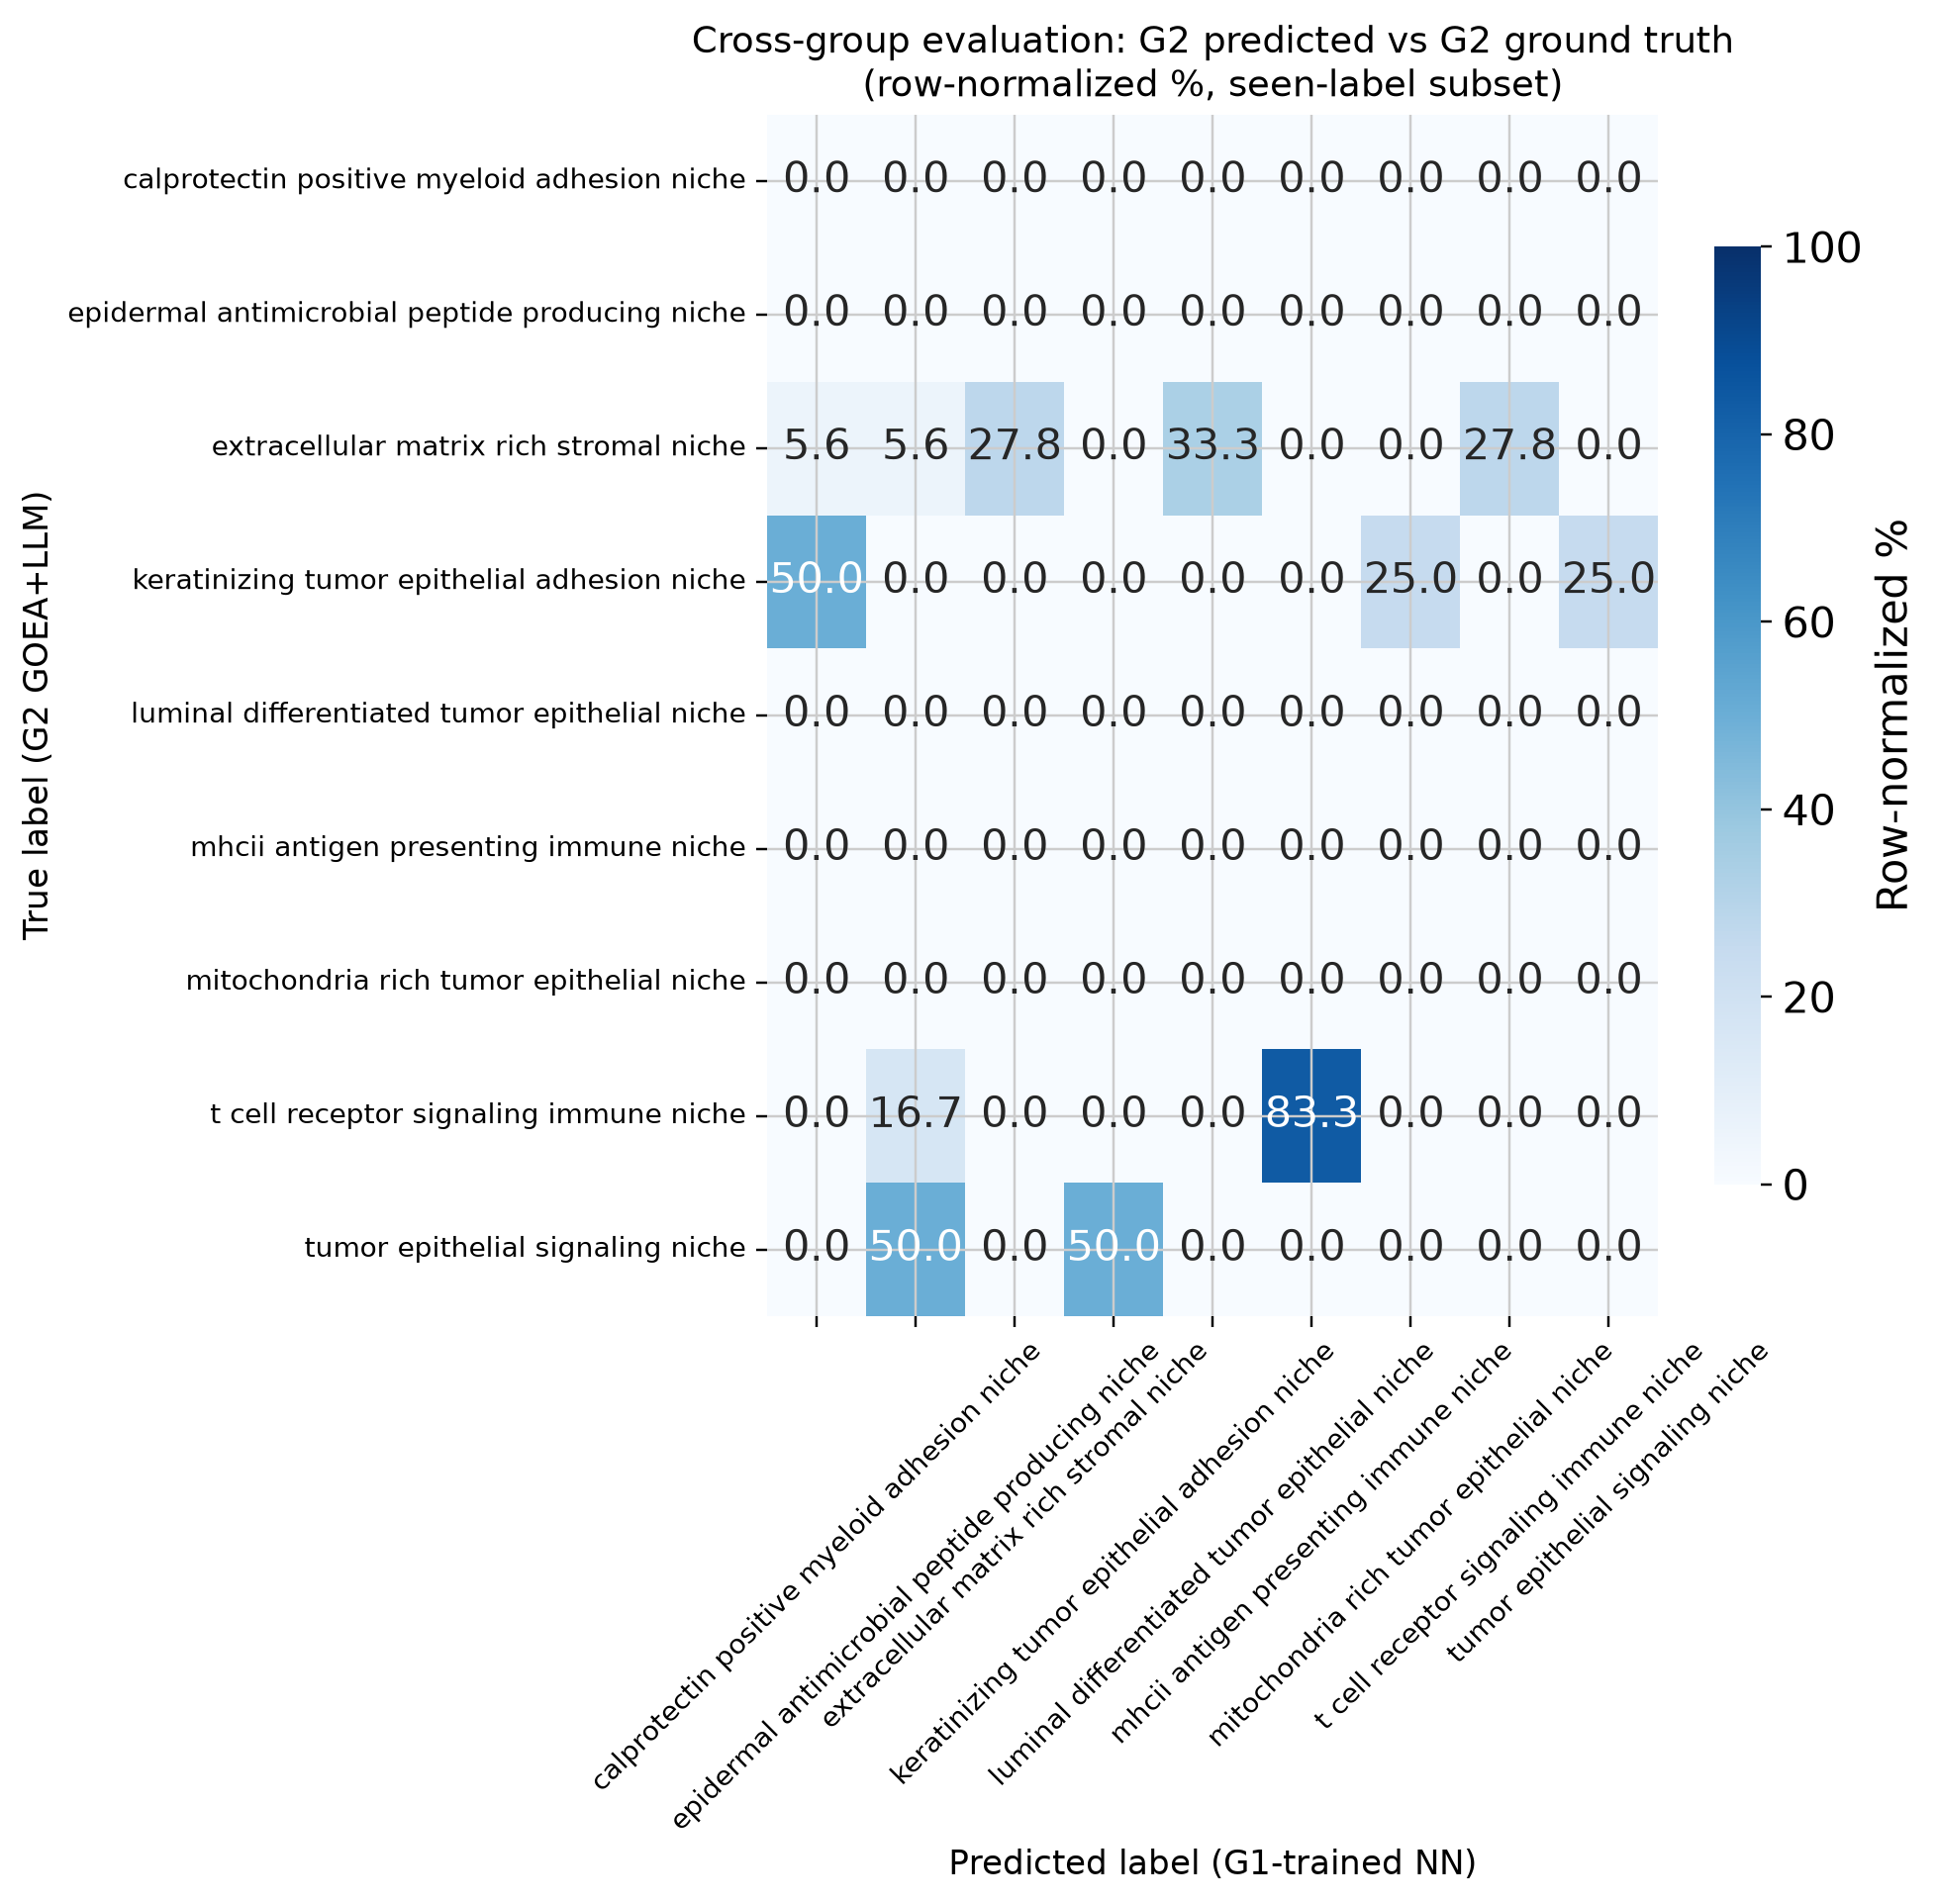

Saved: outputs/v3/nn/g2_confusion_matrix_heatmap.png


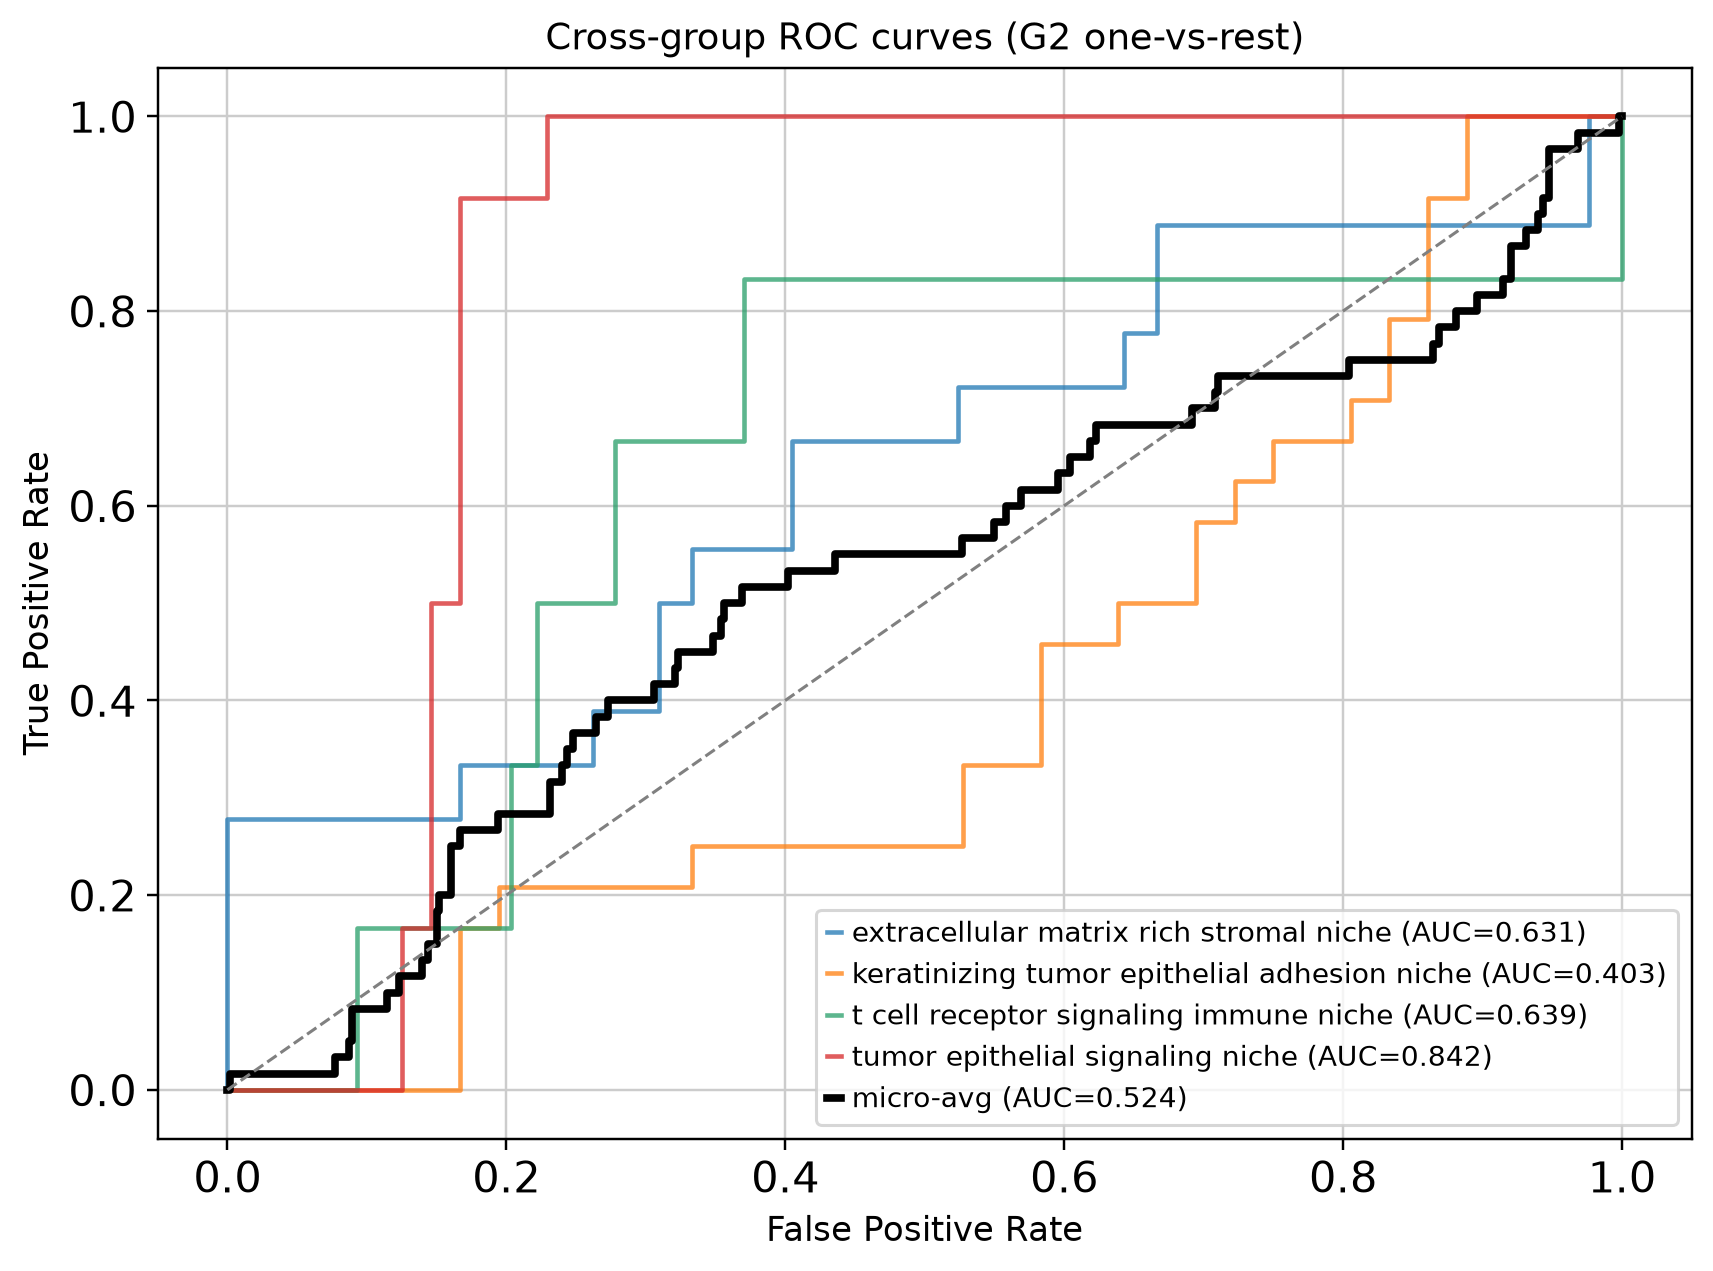


ROC-AUC per class (G2 cross-group):
                                       class  roc_auc
     extracellular matrix rich stromal niche 0.630952
keratinizing tumor epithelial adhesion niche 0.402778
      t cell receptor signaling immune niche 0.638889
            tumor epithelial signaling niche 0.842014
                               overall_micro 0.524028

Evaluation coverage summary:
 g2_niche_rows_total  g2_rows_with_truth  g2_rows_seen_labels  g2_rows_unseen_labels  accuracy  macro_f1  roc_auc_micro
                  60                  60                   60                      0  0.083333  0.048309       0.524028


In [25]:
# Stage 4-D: Cross-group evaluation.
# G2 labels may be fully unseen relative to G1 labels; handle that gracefully.

# Drop rows with no G2 ground truth (niche had no GOEA label).
eval_df = g2_vectors_df.dropna(subset=["true_label_g2"]).copy()

# Separate rows whose true label was seen in G1 training vs. unseen (new biology in G2).
seen_mask   = eval_df["true_label_g2"].isin(class_names)
eval_seen   = eval_df.loc[seen_mask].copy()
eval_unseen = eval_df.loc[~seen_mask].copy()

print(f"G2 niche rows with ground truth    : {len(eval_df)}")
print(f"  Rows with seen labels (evaluable) : {len(eval_seen)}")
print(f"  Rows with unseen labels (excluded): {len(eval_unseen)}")

if eval_seen.empty:
    print("\nNo overlap between G2 true labels and G1 training labels.")
    print("Skipping CM/ROC metrics for this run and writing coverage only.")

    coverage = pd.DataFrame([{
        "g2_niche_rows_total":    len(g2_vectors_df),
        "g2_rows_with_truth":     len(eval_df),
        "g2_rows_seen_labels":    len(eval_seen),
        "g2_rows_unseen_labels":  len(eval_unseen),
        "accuracy":               np.nan,
        "macro_f1":               np.nan,
        "roc_auc_micro":          np.nan,
    }])
    coverage.to_csv(CFG["nn_dir"] / "g2_eval_coverage.csv", index=False)
    print("\nEvaluation coverage summary:")
    print(coverage.to_string(index=False))

else:
    # Encode ground-truth labels using the G1 label encoder.
    y_true_g2 = label_encoder.transform(eval_seen["true_label_g2"])
    y_pred_g2 = label_encoder.transform(eval_seen["predicted_label"])
    prob_cols  = [f"prob_{c}" for c in class_names]
    prob_mat   = eval_seen[prob_cols].to_numpy(dtype=np.float32)

    # Scalar metrics
    acc_g2 = accuracy_score(y_true_g2, y_pred_g2)
    f1_g2  = f1_score(y_true_g2, y_pred_g2, average="macro", zero_division=0)
    print(f"\nCross-group accuracy  (G2 eval): {acc_g2:.4f}")
    print(f"Cross-group macro-F1  (G2 eval): {f1_g2:.4f}")

    # Classification report
    cm_labels   = sorted(set(y_true_g2) | set(y_pred_g2))
    cm_names    = label_encoder.inverse_transform(cm_labels)
    report_dict = classification_report(
        y_true_g2, y_pred_g2,
        labels=cm_labels, target_names=cm_names,
        output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T
    report_df.to_csv(CFG["nn_dir"] / "g2_classification_report.csv")
    print("\nPer-class classification report (G2):")
    print(report_df.to_string())

    # Confusion matrix
    cm_g2      = confusion_matrix(y_true_g2, y_pred_g2, labels=cm_labels)
    cm_g2_norm = confusion_matrix(y_true_g2, y_pred_g2, labels=cm_labels, normalize="true")
    cm_g2_df   = pd.DataFrame(cm_g2_norm * 100, index=cm_names, columns=cm_names)

    cm_g2_df.to_csv(CFG["nn_dir"] / "g2_confusion_matrix.csv")
    pd.DataFrame(cm_g2, index=cm_names, columns=cm_names).to_csv(
        CFG["nn_dir"] / "g2_confusion_matrix_counts.csv"
    )

    fig_cm, ax_cm = plt.subplots(figsize=(max(6, len(cm_names)), max(5, len(cm_names))))
    sns.heatmap(cm_g2_df, annot=True, fmt=".1f", cmap="Blues", ax=ax_cm,
                vmin=0, vmax=100, cbar_kws={"label": "Row-normalized %", "shrink": 0.78})
    ax_cm.set_xlabel("Predicted label (G1-trained NN)", fontsize=11)
    ax_cm.set_ylabel("True label (G2 GOEA+LLM)", fontsize=11)
    ax_cm.set_title("Cross-group evaluation: G2 predicted vs G2 ground truth\n"
                    "(row-normalized %, seen-label subset)", fontsize=12)
    ax_cm.tick_params(axis="x", rotation=45, labelsize=9)
    ax_cm.tick_params(axis="y", rotation=0,  labelsize=9)
    fig_cm.tight_layout()
    fig_cm.savefig(CFG["nn_dir"] / "g2_confusion_matrix_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", CFG["nn_dir"] / "g2_confusion_matrix_heatmap.png")

    # ROC-AUC (one-vs-rest per class + micro-average)
    y_bin_g2    = label_binarize(y_true_g2, classes=np.arange(num_classes))
    roc_records = []
    fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

    for idx in np.unique(y_true_g2):
        if y_bin_g2[:, idx].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin_g2[:, idx], prob_mat[:, idx])
        roc_auc_val = auc(fpr, tpr)
        roc_records.append({"class": class_names[idx], "roc_auc": roc_auc_val})
        ax_roc.plot(fpr, tpr, alpha=0.75, label=f"{class_names[idx]} (AUC={roc_auc_val:.3f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_bin_g2.ravel(), prob_mat.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    ax_roc.plot(fpr_micro, tpr_micro, "k-", lw=2.5, label=f"micro-avg (AUC={auc_micro:.3f})")
    roc_records.append({"class": "overall_micro", "roc_auc": auc_micro})

    ax_roc.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    ax_roc.set_xlabel("False Positive Rate", fontsize=11)
    ax_roc.set_ylabel("True Positive Rate", fontsize=11)
    ax_roc.set_title("Cross-group ROC curves (G2 one-vs-rest)", fontsize=12)
    ax_roc.legend(loc="lower right", fontsize=9)
    fig_roc.tight_layout()
    fig_roc.savefig(CFG["nn_dir"] / "g2_roc_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

    roc_df = pd.DataFrame(roc_records)
    roc_df.to_csv(CFG["nn_dir"] / "g2_roc_auc.csv", index=False)
    print("\nROC-AUC per class (G2 cross-group):")
    print(roc_df.to_string(index=False))

    coverage = pd.DataFrame([{
        "g2_niche_rows_total":    len(g2_vectors_df),
        "g2_rows_with_truth":     len(eval_df),
        "g2_rows_seen_labels":    len(eval_seen),
        "g2_rows_unseen_labels":  len(eval_unseen),
        "accuracy":               acc_g2,
        "macro_f1":               f1_g2,
        "roc_auc_micro":          auc_micro,
    }])
    coverage.to_csv(CFG["nn_dir"] / "g2_eval_coverage.csv", index=False)
    print("\nEvaluation coverage summary:")
    print(coverage.to_string(index=False))

---

## Discussion and Conclusion

### What was validated

| Claim | Evidence |
|-------|----------|
| Niche IDs encode biology consistently within a cohort | Stage 2: G1A vs G1B label agreement (AUC/CM) |
| H&E neighbor composition transfers biology across cohorts | Stage 4: G1-trained NN on G2, validated by independent G2 GOEA+LLM |
| Xenium is not required at inference time | Stage 4: predictions use only H&E features |

### Session Conclusions

- The notebook on disk now reflects the latest prompt and gene-list changes: LLM labeling uses both GOEA output and ranked DE genes, not GOEA alone.
- The training collapse to one class was caused upstream by sparse usable labels, not by the MLP. The Stage 3 fallback to niche_group remains the correct safeguard when human-readable labels collapse.
- DE filtering is now adaptive, and both up- and down-regulated genes remain available for GOEA and prompt construction.
- The GOEA gate was intentionally loosened, but the GO ontology and gene-to-GO download block must stay because enrichment still depends on them.
- Sparse GOEA remains a real outcome for some niches, so the notebook should treat GOEA as evidence for labeling rather than as the sole requirement for labeling.
- The current saved notebook content is up to date, but execution outputs may still need a fresh re-run to fully refresh the visible results after the latest edits.

### Interpretation

- **High G1A/G1B agreement** in Stage 2 means the biological niche structure is consistent
  within the same wsinsight-defined niche space. The neighbor composition is a reliable proxy.

- **High G2 accuracy** in Stage 4 means the learned mapping from H&E composition to niche type
  generalizes across patient cohorts processed independently.

- **Unseen labels** (G2 niche types absent from G1) indicate biology not represented in the G1
  training set. Enlarging G1 or adding more diverse samples would extend coverage.

### Outputs

```
outputs/v3/
  g1a_goea/    markers_all.csv, markers_filt.csv, goea_all.csv, goea_sig.csv, niche_labels.csv
  g1b_goea/    (same structure — independent G1B derivation)
  g2_goea/     (same structure — independent G2 derivation)
  nn/          g1_vectors.csv, g2_vectors.csv, niche_mlp.pt, scaler.pkl, label_encoder.pkl
                  g1ab_label_consistency.csv, g1ab_label_consistency_cm.png
                  g2_predictions_with_truth.csv, g2_confusion_matrix.csv
                  g2_roc_auc.csv, g2_roc_curves.png, g2_eval_coverage.csv
```

## Stage 6 · Limitations and Reviewer FAQ

### 6-A: Study Limitations

1. Cohort size and partition structure.
The current 12-portion design (P1-P12) supports independent-group validation, but uncertainty remains for low-frequency niche classes.

2. Multi-step annotation dependency.
Niche naming depends on DE filtering, GOEA enrichment quality, and LLM interpretation. Errors in upstream steps can propagate to final labels.

3. Marker sparsity and mapping loss.
Gene symbol to Entrez mapping and GO coverage are incomplete for some markers, which can reduce enrichment sensitivity.

4. Class imbalance across niches.
Rare niches may have unstable differential statistics and lower classifier calibration.

5. Domain shift between groups.
Differences in tissue composition, staining, or capture quality between G1 and G2 can lower transfer performance even when biology is partially shared.

---

### 6-B: Reviewer FAQ (Suggested Responses)

**Q1. Why is GOEA+LLM needed instead of direct manual naming?**
A1. GOEA provides reproducible functional evidence for each niche, and LLM labeling is applied on structured GO summaries to standardize human-readable naming across groups.

**Q2. How do you control label leakage in cross-group transfer?**
A2. Niche discovery is run independently by group; G2 labels are derived independently and used as held-out biological ground truth.

**Q3. Could LLM phrasing bias the labels?**
A3. The LLM receives constrained, evidence-based GO term inputs. We also evaluate downstream agreement quantitatively (AUC/CM/consistency) rather than relying only on narrative names.

**Q4. How robust are labels to marker threshold choices?**
A4. Threshold sensitivity can be profiled by rerunning DE/GOEA under small perturbations and measuring label stability and downstream classifier delta.

**Q5. What is the key claim of reference-v2?**
A5. Xenium-guided GOEA+LLM annotation can define biologically interpretable niche labels that are predictable from H&E-derived features and transferable across independently processed groups.

---

### 6-C: Optional Supplementary Robustness Checks

- Bootstrap confidence intervals for AUC/F1 and per-class metrics.
- Multi-seed repeats for DGI, clustering, and NN training.
- Alternative split strategy (sample-wise leave-one-sample-out).
- Stability of GOEA/LLM labels under DE threshold perturbation.
- Rare-niche analysis with minimum-cell filtering and uncertainty reporting.